In [1]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3090
VRAM: 25.8 GB


In [2]:
# Cell 2: Imports & Config
import os, json, glob, re, pickle, warnings
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from lxml import etree

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

warnings.filterwarnings("ignore")

# === PATHS — adjust if your folder is elsewhere ===
DATA_DIR = Path("OSRs")
ATTACK_STIX   = DATA_DIR / "ATTACK/enterprise-attack-v16.1.json"
CWE_XML       = DATA_DIR / "MAPPINGS/cwec_latest.xml"
CAPEC_XML      = DATA_DIR / "MAPPINGS/capec_latest.xml"
KEV_CTID       = DATA_DIR / "kev-07.28.2025_attack-16.1-enterprise.json"
NVD_GLOB       = str(DATA_DIR / "NVD/nvdcve-2.0-*.json")
NIST_MAPPINGS  = DATA_DIR / "NIST800-53-layer-navigator/nist_800_53-rev5_attack-16.1-enterprise_json.json"
NIST_CATALOG   = DATA_DIR / "NIST800_53/nist_800_53.json"

# === DEVICE ===
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# === MODEL CONFIG ===
MODEL_NAME   = "ehsanaghaei/SecureBERT_Plus"
MAX_LENGTH   = 256
NUM_CLASSES  = 137  # parent-level ATT&CK techniques
THRESHOLD    = 0.45

# === TRAINING CONFIG (RTX 3070 8GB safe) ===
BATCH_SIZE       = 256
GRAD_ACCUM_STEPS = 4   # effective batch = 64
EPOCHS           = 10
LR               = 2e-5
WEIGHT_DECAY     = 0.01
WARMUP_RATIO     = 0.1

# === TIER WEIGHTS ===
TIER_WEIGHTS = {
    "gold":            1.0,
    "gold+transitive": 0.6,
    "transitive":      0.2,
}

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✅ Config loaded.")

c:\Users\OA\Desktop\New Work\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
✅ Config loaded.


In [3]:
# Cell 3: Parse ATT&CK STIX → 105-class technique index + parent map

with open(ATTACK_STIX, "r") as f:
    stix_data = json.load(f)

# Extract all techniques (not deprecated/revoked)
all_techniques = []
for obj in stix_data["objects"]:
    if obj.get("type") == "attack-pattern" and not obj.get("revoked", False) and not obj.get("x_mitre_deprecated", False):
        # Get external ID (e.g. T1059, T1059.001)
        ext_refs = obj.get("external_references", [])
        tid = None
        for ref in ext_refs:
            if ref.get("source_name") == "mitre-attack" and ref.get("external_id", "").startswith("T"):
                tid = ref["external_id"]
                break
        if tid:
            all_techniques.append({
                "tid": tid,
                "name": obj.get("name", ""),
                "is_subtechnique": obj.get("x_mitre_is_subtechnique", False),
            })

print(f"Total techniques (incl. sub): {len(all_techniques)}")

# Build sub-technique → parent map (T1059.001 → T1059)
sub_to_parent = {}
for t in all_techniques:
    if t["is_subtechnique"] and "." in t["tid"]:
        parent = t["tid"].split(".")[0]
        sub_to_parent[t["tid"]] = parent

# Get unique parent-level technique IDs
parent_techniques = sorted(set(
    t["tid"] for t in all_techniques if not t["is_subtechnique"]
))

# Verify we get 105 (or close — depends on ATT&CK version)
print(f"Parent-level techniques: {len(parent_techniques)}")

# Build index mappings
tech2idx = {t: i for i, t in enumerate(parent_techniques)}
idx2tech = {i: t for t, i in tech2idx.items()}

# Helper: collapse any technique ID to parent
def collapse_to_parent(tid):
    """T1059.001 → T1059, T1059 → T1059"""
    if "." in tid:
        return tid.split(".")[0]
    return tid

# Build name lookup for later reporting
tech_names = {}
for t in all_techniques:
    if not t["is_subtechnique"]:
        tech_names[t["tid"]] = t["name"]

print(f"\nFirst 10 techniques: {parent_techniques[:10]}")
print(f"Sub-to-parent entries: {len(sub_to_parent)}")
print("✅ ATT&CK STIX parsed.")

Total techniques (incl. sub): 656
Parent-level techniques: 203

First 10 techniques: ['T1001', 'T1003', 'T1005', 'T1006', 'T1007', 'T1008', 'T1010', 'T1011', 'T1012', 'T1014']
Sub-to-parent entries: 453
✅ ATT&CK STIX parsed.


In [4]:
# Quick check — what's the parent map variable called?
for var_name in ['parent_map', 'sub_to_parent', 'parent_technique_map', 'technique_parent_map']:
    if var_name in dir():
        print(f"Found: {var_name}")

Found: sub_to_parent


In [5]:
# Cell 4: Parse CWE XML → CWE-to-CAPEC map (Targeted relationships only)

tree = etree.parse(str(CWE_XML))
root = tree.getroot()

# CWE XML uses a namespace
ns = {"cwe": root.nsmap.get(None, "")}
if not ns["cwe"]:
    # Try to extract from tag
    ns["cwe"] = re.match(r"\{(.+?)\}", root.tag).group(1) if "{" in root.tag else ""

print(f"CWE namespace: {ns['cwe'][:60]}...")

cwe_to_capec = defaultdict(set)
cwe_to_capec_all = defaultdict(set)  # including non-targeted, for comparison

# Parse weaknesses
weaknesses = root.findall(f".//{{{ns['cwe']}}}Weakness")
print(f"Total CWE entries: {len(weaknesses)}")

targeted_rels = {"ChildOf", "ParentOf"}
parsed_count = 0

for weakness in weaknesses:
    cwe_id = f"CWE-{weakness.get('ID')}"
    
    # Look for Related_Attack_Patterns
    related = weakness.findall(f".//{{{ns['cwe']}}}Related_Attack_Pattern")
    for rap in related:
        capec_id = rap.get("CAPEC_ID")
        nature = rap.get("Nature", "")
        if capec_id:
            capec_str = f"CAPEC-{capec_id}"
            cwe_to_capec_all[cwe_id].add(capec_str)
            # Only keep Targeted (ChildOf/ParentOf) relationships
            # Note: CWE→CAPEC uses "Nature" but the values may differ
            # In CWE XML, Related_Attack_Pattern doesn't always have Nature
            # so we keep all direct CWE→CAPEC links (they are curated)
            cwe_to_capec[cwe_id].add(capec_str)
            parsed_count += 1

print(f"CWE→CAPEC mappings (targeted): {parsed_count}")
print(f"CWEs with CAPEC links: {len(cwe_to_capec)}")
print(f"\nSample: CWE-79 → {cwe_to_capec.get('CWE-79', 'NOT FOUND')}")
print(f"Sample: CWE-89 → {cwe_to_capec.get('CWE-89', 'NOT FOUND')}")
print("✅ CWE XML parsed.")

CWE namespace: http://cwe.mitre.org/cwe-7...
Total CWE entries: 969
CWE→CAPEC mappings (targeted): 1212
CWEs with CAPEC links: 336

Sample: CWE-79 → {'CAPEC-592', 'CAPEC-588', 'CAPEC-85', 'CAPEC-591', 'CAPEC-209', 'CAPEC-63'}
Sample: CWE-89 → {'CAPEC-66', 'CAPEC-110', 'CAPEC-109', 'CAPEC-470', 'CAPEC-7', 'CAPEC-108'}
✅ CWE XML parsed.


In [6]:
# Cell 5: Parse CAPEC XML + ATT&CK STIX → CAPEC-to-ATT&CK map

tree_capec = etree.parse(str(CAPEC_XML))
root_capec = tree_capec.getroot()
ns_capec = root_capec.nsmap.get(None, "")

capec_to_attack = defaultdict(set)

# --- Source 1: CAPEC XML Taxonomy_Mappings ---
attack_patterns = root_capec.findall(f".//{{{ns_capec}}}Attack_Pattern")
print(f"Total CAPEC entries: {len(attack_patterns)}")

for ap in attack_patterns:
    capec_id = f"CAPEC-{ap.get('ID')}"
    tax_mappings = ap.findall(f".//{{{ns_capec}}}Taxonomy_Mapping")
    for tm in tax_mappings:
        taxonomy_name = tm.get("Taxonomy_Name", "").upper()
        if "ATTACK" in taxonomy_name or "ATT&CK" in taxonomy_name:
            entry_id_el = tm.find(f"{{{ns_capec}}}Entry_ID")
            if entry_id_el is not None and entry_id_el.text:
                raw_tid = entry_id_el.text.strip()
                if not raw_tid.startswith("T"):
                    raw_tid = f"T{raw_tid}"
                parent_tid = collapse_to_parent(raw_tid)
                if parent_tid in tech2idx:
                    capec_to_attack[capec_id].add(parent_tid)

src1_capecs = len([v for v in capec_to_attack.values() if v])
src1_mappings = sum(len(v) for v in capec_to_attack.values())
print(f"Source 1 (CAPEC XML): {src1_capecs} CAPECs, {src1_mappings} mappings")

# --- Source 2: ATT&CK STIX external_references (incl. revoked techniques) ---
# Revoked techniques still carry valid CAPEC refs; follow revoked-by to current TID

# Build revoked-by map
revoked_by = {}
for obj in stix_data["objects"]:
    if obj.get("type") == "relationship" and obj.get("relationship_type") == "revoked-by":
        revoked_by[obj["source_ref"]] = obj["target_ref"]

# Build STIX ID → parent TID map
stix_id_to_tid = {}
for obj in stix_data["objects"]:
    if obj.get("type") == "attack-pattern":
        for ref in obj.get("external_references", []):
            if ref.get("source_name") == "mitre-attack" and ref.get("external_id", "").startswith("T"):
                stix_id_to_tid[obj["id"]] = collapse_to_parent(ref["external_id"])
                break

# Harvest CAPEC links from all attack-patterns (including revoked)
stix_additions = 0
for obj in stix_data["objects"]:
    if obj.get("type") != "attack-pattern":
        continue
    
    ext_refs = obj.get("external_references", [])
    tid = None
    capecs = []
    
    for ref in ext_refs:
        if ref.get("source_name") == "mitre-attack" and ref.get("external_id", "").startswith("T"):
            tid = ref["external_id"]
        if ref.get("source_name", "").lower() == "capec":
            ext_id = ref.get("external_id", "")
            if ext_id:
                capec_str = f"CAPEC-{ext_id}" if not ext_id.startswith("CAPEC") else ext_id
                capecs.append(capec_str)
    
    if not capecs:
        continue
    
    # Resolve current technique (follow revoked-by if needed)
    if obj.get("revoked", False):
        current_stix_id = revoked_by.get(obj["id"])
        if current_stix_id and current_stix_id in stix_id_to_tid:
            parent_tid = stix_id_to_tid[current_stix_id]
        elif tid:
            parent_tid = collapse_to_parent(tid)
        else:
            continue
    elif tid:
        parent_tid = collapse_to_parent(tid)
    else:
        continue
    
    if parent_tid in tech2idx:
        for c in capecs:
            before = len(capec_to_attack[c])
            capec_to_attack[c].add(parent_tid)
            stix_additions += len(capec_to_attack[c]) - before

total_capecs = len([v for v in capec_to_attack.values() if v])
total_mappings = sum(len(v) for v in capec_to_attack.values())
print(f"Source 2 (ATT&CK STIX revoked): +{stix_additions} new mappings")
print(f"\nCombined: {total_capecs} CAPECs → {total_mappings} ATT&CK mappings")

print(f"\nSample: CAPEC-1 → {capec_to_attack.get('CAPEC-1', 'NOT FOUND')}")
print(f"Sample: CAPEC-66 → {capec_to_attack.get('CAPEC-66', 'NOT FOUND')}")
print("✅ CAPEC→ATT&CK parsed (both sources merged).")

Total CAPEC entries: 615
Source 1 (CAPEC XML): 177 CAPECs, 238 mappings
Source 2 (ATT&CK STIX revoked): +1 new mappings

Combined: 178 CAPECs → 239 ATT&CK mappings

Sample: CAPEC-1 → {'T1574'}
Sample: CAPEC-66 → NOT FOUND
✅ CAPEC→ATT&CK parsed (both sources merged).


In [7]:
# Cell 6 (RE-RUN): Rebuild BRON mask with merged capec_to_attack

cwe_to_attack = {}
chain_stats = {"cwe_with_path": 0, "cwe_no_capec": 0, "cwe_capec_no_attack": 0}

for cwe_id, capec_ids in cwe_to_capec.items():
    attack_ids = set()
    for capec_id in capec_ids:
        if capec_id in capec_to_attack:
            attack_ids.update(capec_to_attack[capec_id])
    
    if attack_ids:
        cwe_to_attack[cwe_id] = frozenset(attack_ids)
        chain_stats["cwe_with_path"] += 1
    else:
        chain_stats["cwe_capec_no_attack"] += 1

chain_stats["cwe_no_capec"] = len(weaknesses) - len(cwe_to_capec)

all_reachable = set()
for techs in cwe_to_attack.values():
    all_reachable.update(techs)

print("=== BRON Mask Coverage (after STIX merge) ===")
print(f"CWEs with full path: {chain_stats['cwe_with_path']}")
print(f"CWEs with CAPEC but no ATT&CK: {chain_stats['cwe_capec_no_attack']}")
print(f"CWEs with no CAPEC: {chain_stats['cwe_no_capec']}")
print(f"Reachable techniques: {len(all_reachable)}/{NUM_CLASSES}")
print(f"Avg techniques per constrained CWE: {np.mean([len(v) for v in cwe_to_attack.values()]):.1f}")
print(f"\nFor the paper: mask constrains {chain_stats['cwe_with_path']} CWEs,")
print(f"falls back to unconstrained for {chain_stats['cwe_capec_no_attack'] + chain_stats['cwe_no_capec']} CWEs.")
print(f"This is a MITRE ecosystem limitation, not a pipeline bug.")
print("✅ BRON mask rebuilt.")

=== BRON Mask Coverage (after STIX merge) ===
CWEs with full path: 149
CWEs with CAPEC but no ATT&CK: 187
CWEs with no CAPEC: 633
Reachable techniques: 95/137
Avg techniques per constrained CWE: 3.0

For the paper: mask constrains 149 CWEs,
falls back to unconstrained for 820 CWEs.
This is a MITRE ecosystem limitation, not a pipeline bug.
✅ BRON mask rebuilt.


In [8]:
# Cell 7: Parse KEV/CTID gold label file → gold_labels dict

with open(KEV_CTID, "r", encoding="utf-8") as f:
    kev_data = json.load(f)

# Inspect top-level keys to adapt parser
print(f"Top-level keys: {list(kev_data.keys())[:10]}")

mapping_objects = kev_data.get("mapping_objects", [])
print(f"Total mapping objects: {len(mapping_objects)}")

if mapping_objects:
    print(f"Sample entry: {json.dumps(mapping_objects[0], indent=2)}")

# Build gold_labels: {CVE-ID: set(parent T-IDs)}
gold_labels = defaultdict(set)
skipped = 0

for entry in mapping_objects:
    cve_id = entry.get("capability_id", "")
    attack_id = entry.get("attack_object_id", "")
    
    if not cve_id.startswith("CVE-") or not attack_id.startswith("T"):
        skipped += 1
        continue
    
    parent_tid = collapse_to_parent(attack_id)
    if parent_tid in tech2idx:
        gold_labels[cve_id].add(parent_tid)

print(f"\n=== Gold Labels ===")
print(f"Gold CVEs: {len(gold_labels)}")
print(f"Total gold (CVE, technique) pairs: {sum(len(v) for v in gold_labels.values())}")
print(f"Avg techniques per gold CVE: {np.mean([len(v) for v in gold_labels.values()]):.2f}")
print(f"Skipped entries: {skipped}")

tech_counts = [len(v) for v in gold_labels.values()]
print(f"\nTechniques per gold CVE — min: {min(tech_counts)}, max: {max(tech_counts)}, "
      f"median: {np.median(tech_counts):.0f}")

gold_tech_counter = Counter()
for techs in gold_labels.values():
    gold_tech_counter.update(techs)
print(f"\nTop 10 gold techniques:")
for tid, count in gold_tech_counter.most_common(10):
    print(f"  {tid} ({tech_names.get(tid, '?')}): {count}")

print("\n✅ Gold labels parsed.")

Top-level keys: ['metadata', 'mapping_objects']
Total mapping objects: 1183
Sample entry: {
  "capability_id": "CVE-2024-34102",
  "capability_description": "Adobe Commerce and Magento Open Source Improper Restriction of XML External Entity Reference (XXE) Vulnerability",
  "mapping_type": "exploitation_technique",
  "attack_object_id": "T1190",
  "attack_object_name": "Exploit Public-Facing Application",
  "capability_group": "xxe",
  "comments": "This vulnerability is exploited by sending a crafted XML document that references external entities with the likely goal of accessing local data.",
  "references": [
    "https://www.assetnote.io/resources/research/why-nested-deserialization-is-harmful-magento-xxe-cve-2024-34102",
    "https://www.vicarius.io/vsociety/posts/cosmicsting-critical-unauthenticated-xxe-vulnerability-in-adobe-commerce-and-magento-cve-2024-34102"
  ],
  "status": "complete",
  "mapping_framework_version": "7/28/2025"
}

=== Gold Labels ===
Gold CVEs: 419
Total gold

In [9]:
# New Cell 8: Full NVD parser with CVSS extraction

import json, os, glob

nvd_dir = "OSRs"
nvd_files = sorted(glob.glob(NVD_GLOB))
print(f"NVD files: {len(nvd_files)}")

nvd_records = []

for fpath in tqdm(nvd_files, desc="Parsing NVD"):
    with open(fpath, encoding="utf-8") as f:
        data = json.load(f)
    
    items = data.get("vulnerabilities", data.get("CVE_Items", []))
    
    for item in items:
        cve = item.get("cve", item)
        
        # CVE ID
        cve_id = cve.get("id", cve.get("CVE_data_meta", {}).get("ID", ""))
        if not cve_id:
            continue
        
        # Description
        desc = ""
        descs = cve.get("descriptions", [])
        if descs:
            for d in descs:
                if d.get("lang") == "en":
                    desc = d["value"]
                    break
        if not desc:
            # NVD 1.0 format
            desc_data = cve.get("description", {}).get("description_data", [])
            for d in desc_data:
                if d.get("lang") == "en":
                    desc = d["value"]
                    break
        
        if not desc or "** REJECT **" in desc or "** RESERVED **" in desc:
            continue
        
        # CWEs
        cwes = []
        weaknesses = cve.get("weaknesses", [])
        for w in weaknesses:
            for d in w.get("description", []):
                val = d.get("value", "")
                if val.startswith("CWE-") and val != "CWE-noinfo":
                    cwes.append(val)
        if not cwes:
            # NVD 1.0
            problemtype = cve.get("problemtype", {}).get("problemtype_data", [])
            for pt in problemtype:
                for d in pt.get("description", []):
                    val = d.get("value", "")
                    if val.startswith("CWE-") and val != "CWE-noinfo":
                        cwes.append(val)
        
        # CVSS — prefer v3.1 > v3.0 > v2.0
        metrics = cve.get("metrics", item.get("impact", {}))
        
        cvss_version = None
        cvss_score = None
        cvss_vector = None
        attack_vector = None
        attack_complexity = None
        privileges_required = None
        user_interaction = None
        scope = None
        conf_impact = None
        integ_impact = None
        avail_impact = None
        
        # Try CVSS v3.1
        v31 = metrics.get("cvssMetricV31", metrics.get("baseMetricV3", None))
        if v31:
            if isinstance(v31, list):
                v31 = v31[0]
            cvss_data = v31.get("cvssData", v31.get("cvssV3", {}))
            cvss_version = "3.1"
            cvss_score = cvss_data.get("baseScore")
            cvss_vector = cvss_data.get("vectorString")
            attack_vector = cvss_data.get("attackVector")
            attack_complexity = cvss_data.get("attackComplexity")
            privileges_required = cvss_data.get("privilegesRequired")
            user_interaction = cvss_data.get("userInteraction")
            scope = cvss_data.get("scope")
            conf_impact = cvss_data.get("confidentialityImpact")
            integ_impact = cvss_data.get("integrityImpact")
            avail_impact = cvss_data.get("availabilityImpact")
        
        # Try CVSS v3.0
        if not cvss_version:
            v30 = metrics.get("cvssMetricV30", None)
            if v30:
                if isinstance(v30, list):
                    v30 = v30[0]
                cvss_data = v30.get("cvssData", {})
                cvss_version = "3.0"
                cvss_score = cvss_data.get("baseScore")
                cvss_vector = cvss_data.get("vectorString")
                attack_vector = cvss_data.get("attackVector")
                attack_complexity = cvss_data.get("attackComplexity")
                privileges_required = cvss_data.get("privilegesRequired")
                user_interaction = cvss_data.get("userInteraction")
                scope = cvss_data.get("scope")
                conf_impact = cvss_data.get("confidentialityImpact")
                integ_impact = cvss_data.get("integrityImpact")
                avail_impact = cvss_data.get("availabilityImpact")
        
        # Fall back to CVSS v2
        if not cvss_version:
            v2 = metrics.get("cvssMetricV2", metrics.get("baseMetricV2", None))
            if v2:
                if isinstance(v2, list):
                    v2 = v2[0]
                cvss_data = v2.get("cvssData", v2.get("cvssV2", {}))
                cvss_version = "2.0"
                cvss_score = cvss_data.get("baseScore")
                cvss_vector = cvss_data.get("vectorString")
                # Map v2 fields to v3-like names
                av = cvss_data.get("accessVector", "")
                attack_vector = {"NETWORK": "NETWORK", "ADJACENT_NETWORK": "ADJACENT_NETWORK",
                                 "LOCAL": "LOCAL", "PHYSICAL": "PHYSICAL"}.get(av, av)
                attack_complexity = cvss_data.get("accessComplexity")
                privileges_required = cvss_data.get("authentication", "")
                # Map auth to privileges: NONE→NONE, SINGLE→LOW, MULTIPLE→HIGH
                privileges_required = {"NONE": "NONE", "SINGLE_INSTANCE": "LOW",
                                       "SINGLE": "LOW", "MULTIPLE_INSTANCES": "HIGH",
                                       "MULTIPLE": "HIGH"}.get(privileges_required, privileges_required)
                user_interaction = None  # not in v2
                scope = None  # not in v2
                conf_impact = cvss_data.get("confidentialityImpact")
                integ_impact = cvss_data.get("integrityImpact")
                avail_impact = cvss_data.get("availabilityImpact")
        
        # Year
        year = None
        if cve_id.startswith("CVE-"):
            try:
                year = int(cve_id.split("-")[1])
            except:
                pass
        
        nvd_records.append({
            "cve_id": cve_id,
            "description": desc,
            "cwes": cwes,
            "cvss_version": cvss_version,
            "cvss_score": cvss_score,
            "cvss_vector": cvss_vector,
            "attack_vector": attack_vector,
            "attack_complexity": attack_complexity,
            "privileges_required": privileges_required,
            "user_interaction": user_interaction,
            "scope": scope,
            "conf_impact": conf_impact,
            "integ_impact": integ_impact,
            "avail_impact": avail_impact,
            "year": year,
        })

nvd_df = pd.DataFrame(nvd_records)
print(f"\nTotal CVEs parsed: {len(nvd_df):,}")
print(f"With CVSS v3.x: {(nvd_df['cvss_version'].isin(['3.0','3.1'])).sum():,}")
print(f"With CVSS v2 only: {(nvd_df['cvss_version'] == '2.0').sum():,}")
print(f"No CVSS: {nvd_df['cvss_version'].isna().sum():,}")
print(f"With CWEs: {nvd_df['cwes'].apply(len).gt(0).sum():,}")

print(f"\nAttack vector distribution:")
print(nvd_df["attack_vector"].value_counts())
print(f"\nPrivileges required distribution:")
print(nvd_df["privileges_required"].value_counts())

print("\n✅ NVD parsed with full CVSS.")

NVD files: 25


Parsing NVD: 100%|██████████| 25/25 [00:30<00:00,  1.22s/it]



Total CVEs parsed: 332,622
With CVSS v3.x: 238,531
With CVSS v2 only: 72,483
No CVSS: 21,608
With CWEs: 258,939

Attack vector distribution:
attack_vector
NETWORK             233353
LOCAL                66679
ADJACENT_NETWORK      8614
PHYSICAL              2368
Name: count, dtype: int64

Privileges required distribution:
privileges_required
NONE    200110
LOW      88793
HIGH     22111
Name: count, dtype: int64

✅ NVD parsed with full CVSS.


In [10]:
# New Cell 9: Build enriched dataset with CVSS-informed labels

def build_enriched_description(row):
    """Prepend structured CVSS features to description — gives model discriminative signal"""
    parts = []
    
    # CVSS structured prefix
    tags = []
    if pd.notna(row.get("attack_vector")):
        tags.append(f"AV:{row['attack_vector']}")
    if pd.notna(row.get("attack_complexity")):
        tags.append(f"AC:{row['attack_complexity']}")
    if pd.notna(row.get("privileges_required")):
        tags.append(f"PR:{row['privileges_required']}")
    if pd.notna(row.get("user_interaction")):
        tags.append(f"UI:{row['user_interaction']}")
    if pd.notna(row.get("scope")):
        tags.append(f"S:{row['scope']}")
    if pd.notna(row.get("conf_impact")):
        tags.append(f"C:{row['conf_impact']}")
    if pd.notna(row.get("integ_impact")):
        tags.append(f"I:{row['integ_impact']}")
    if pd.notna(row.get("avail_impact")):
        tags.append(f"A:{row['avail_impact']}")
    if pd.notna(row.get("cvss_score")):
        tags.append(f"SCORE:{row['cvss_score']}")
    
    if tags:
        parts.append("[" + " ".join(tags) + "]")
    
    # CWE IDs
    if row.get("cwes") and len(row["cwes"]) > 0:
        parts.append("[CWE: " + ", ".join(row["cwes"][:5]) + "]")
    
    # Original description
    parts.append(row["description"])
    
    return " ".join(parts)


# Merge NVD with gold labels
nvd_enriched = nvd_df.copy()
nvd_enriched["enriched_desc"] = nvd_enriched.apply(build_enriched_description, axis=1)

# Add gold labels
nvd_enriched["gold_techniques"] = nvd_enriched["cve_id"].map(
    lambda x: gold_labels.get(x, [])
)
nvd_enriched["has_gold"] = nvd_enriched["gold_techniques"].apply(len) > 0

# Add transitive labels (CWE → CAPEC → ATT&CK)
def get_transitive_techniques(cwes):
    techs = set()
    for cwe in cwes:
        if cwe in cwe_to_attack:
            for t in cwe_to_attack[cwe]:
                # Map sub-techniques to parents
                parent = sub_to_parent.get(t, t)
                if parent in tech2idx:
                    techs.add(parent)
    return sorted(techs)

nvd_enriched["transitive_techniques"] = nvd_enriched["cwes"].apply(get_transitive_techniques)

# Assign final labels + tier
def assign_labels(row):
    gold = set(row["gold_techniques"])
    trans = set(row["transitive_techniques"])
    
    # Filter gold to only active techniques
    gold = {t for t in gold if t in tech2idx}
    trans = {t for t in trans if t in tech2idx}
    
    if gold and trans:
        return sorted(gold | trans), "gold+transitive"
    elif gold:
        return sorted(gold), "gold"
    elif trans:
        return sorted(trans), "transitive"
    else:
        return [], "none"

results = nvd_enriched.apply(assign_labels, axis=1)
nvd_enriched["techniques"] = results.apply(lambda x: x[0])
nvd_enriched["tier"] = results.apply(lambda x: x[1])
nvd_enriched["num_techniques"] = nvd_enriched["techniques"].apply(len)

# Filter: must have at least 1 technique
dataset_df = nvd_enriched[nvd_enriched["num_techniques"] > 0].copy()

# Mark noisy: >15 techniques is suspicious (template explosion)
dataset_df["noisy"] = dataset_df["num_techniques"] > 15

# Cap max techniques at 10 for transitive-only to reduce template noise
def cap_transitive_labels(row):
    if row["tier"] == "transitive" and row["num_techniques"] > 10:
        # Keep only the techniques with highest global frequency (most likely correct)
        techs = row["techniques"]
        # Sort by frequency — most common techniques are more likely correct
        techs_sorted = sorted(techs, key=lambda t: tech_freq.get(t, 0), reverse=True)
        return techs_sorted[:10]
    return row["techniques"]

# We need tech_freq — rebuild it
tech_freq = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        tech_freq[t] += 1

dataset_df["techniques"] = dataset_df.apply(cap_transitive_labels, axis=1)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)
dataset_df["noisy"] = dataset_df["num_techniques"] > 15

# Build final columns
dataset_df = dataset_df[[
    "cve_id", "enriched_desc", "description", "cwes", "techniques", 
    "num_techniques", "tier", "noisy", "cvss_score", "cvss_version",
    "attack_vector", "attack_complexity", "privileges_required",
    "user_interaction", "scope", "conf_impact", "integ_impact", 
    "avail_impact", "year"
]].reset_index(drop=True)

print(f"Dataset size: {len(dataset_df):,}")
print(f"\nTier distribution:")
print(dataset_df["tier"].value_counts())
print(f"\nLabels per sample: mean={dataset_df['num_techniques'].mean():.1f}, "
      f"median={dataset_df['num_techniques'].median():.0f}, "
      f"max={dataset_df['num_techniques'].max()}")
print(f"Noisy samples: {dataset_df['noisy'].sum():,}")

# Check label set diversity improved
label_sets = dataset_df["techniques"].apply(lambda x: tuple(sorted(x)))
print(f"\nUnique label sets: {label_sets.nunique()} / {len(dataset_df):,}")

# Sample enriched descriptions
print(f"\n--- Sample enriched descriptions ---")
for _, row in dataset_df.sample(3, random_state=42).iterrows():
    print(f"\n{row['cve_id']} | tier={row['tier']} | {row['num_techniques']} labels")
    print(f"  {row['enriched_desc'][:200]}...")
    print(f"  Techs: {row['techniques'][:5]}")

print("\n✅ Enriched dataset built.")

Dataset size: 77,609

Tier distribution:
tier
transitive         77190
gold                 295
gold+transitive      124
Name: count, dtype: int64

Labels per sample: mean=4.9, median=4, max=29
Noisy samples: 12

Unique label sets: 718 / 77,609

--- Sample enriched descriptions ---

CVE-2020-3893 | tier=transitive | 6 labels
  [AV:LOCAL AC:LOW PR:NONE UI:REQUIRED S:UNCHANGED C:HIGH I:HIGH A:HIGH SCORE:7.8] [CWE: CWE-20, CWE-787] A memory corruption issue was addressed with improved input validation. This issue is fixed in m...
  Techs: ['T1027', 'T1036', 'T1539', 'T1553', 'T1562']

CVE-2021-44388 | tier=transitive | 6 labels
  [AV:NETWORK AC:LOW PR:LOW UI:NONE S:CHANGED C:NONE I:NONE A:HIGH SCORE:7.7] [CWE: CWE-20, CWE-20] A denial of service vulnerability exists in the cgiserver.cgi JSON command parser functionality of reo...
  Techs: ['T1027', 'T1036', 'T1539', 'T1553', 'T1562']

CVE-2024-31323 | tier=transitive | 3 labels
  [AV:LOCAL AC:LOW PR:LOW UI:NONE S:UNCHANGED C:HIGH I:HIGH A

In [11]:
# Cell 9b: CVSS-informed label filtering

# Define which techniques are plausible given CVSS attributes
# Based on ATT&CK technique definitions

TECHNIQUE_CVSS_RULES = {
    # Network-only techniques — remove if AV:LOCAL/PHYSICAL
    "T1040": {"attack_vector": {"NETWORK", "ADJACENT_NETWORK"}},  # Network Sniffing
    "T1499": {"attack_vector": {"NETWORK", "ADJACENT_NETWORK"}},  # Endpoint DoS
    "T1498": {"attack_vector": {"NETWORK", "ADJACENT_NETWORK"}},  # Network DoS
    "T1557": {"attack_vector": {"NETWORK", "ADJACENT_NETWORK"}},  # Adversary-in-the-Middle
    "T1071": {"attack_vector": {"NETWORK", "ADJACENT_NETWORK"}},  # Application Layer Protocol
    
    # Requires privileges — remove if PR:NONE
    "T1548": {"privileges_required": {"LOW", "HIGH"}},  # Abuse Elevation Control
    "T1134": {"privileges_required": {"LOW", "HIGH"}},  # Access Token Manipulation
    
    # Local-only techniques — remove if AV:NETWORK only
    "T1542": {"attack_vector": {"LOCAL", "PHYSICAL"}},  # Pre-OS Boot
    "T1014": {"attack_vector": {"LOCAL"}},  # Rootkit
    "T1547": {"attack_vector": {"LOCAL"}},  # Boot or Logon Autostart
    
    # Requires user interaction
    "T1204": {"user_interaction": {"REQUIRED"}},  # User Execution
    "T1566": {"user_interaction": {"REQUIRED"}},  # Phishing
    
    # Confidentiality impact needed
    "T1539": {"conf_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Steal Web Session Cookie
    "T1005": {"conf_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Data from Local System
    "T1119": {"conf_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Automated Collection
    
    # Integrity impact needed
    "T1027": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Obfuscated Files
    "T1036": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Masquerading
    "T1553": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Subvert Trust Controls
    
    # Availability impact — DoS techniques
    "T1489": {"avail_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Service Stop
    "T1561": {"avail_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Disk Wipe
}

def filter_techniques_by_cvss(row):
    """Remove implausible techniques based on CVSS attributes"""
    if row["tier"] == "gold" or row["tier"] == "gold+transitive":
        return row["techniques"]  # Don't touch gold labels
    
    filtered = []
    for tech in row["techniques"]:
        if tech not in TECHNIQUE_CVSS_RULES:
            filtered.append(tech)  # No rule — keep it
            continue
        
        rules = TECHNIQUE_CVSS_RULES[tech]
        keep = True
        for field, valid_values in rules.items():
            actual = row.get(field)
            if pd.notna(actual) and actual not in valid_values:
                keep = False
                break
        if keep:
            filtered.append(tech)
    
    return filtered if filtered else row["techniques"]  # Never return empty

# Apply filtering
before_avg = dataset_df["num_techniques"].mean()
dataset_df["techniques"] = dataset_df.apply(filter_techniques_by_cvss, axis=1)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)
after_avg = dataset_df["num_techniques"].mean()

# Recheck diversity
label_sets = dataset_df["techniques"].apply(lambda x: tuple(sorted(x)))
unique_after = label_sets.nunique()

print(f"Avg labels: {before_avg:.1f} → {after_avg:.1f}")
print(f"Unique label sets: 718 → {unique_after}")
print(f"Max labels: {dataset_df['num_techniques'].max()}")

# Check the same two CVEs from before
print(f"\n--- Spot check ---")
for cve_id in ["CVE-2020-3893", "CVE-2021-44388"]:
    row = dataset_df[dataset_df["cve_id"] == cve_id]
    if len(row) > 0:
        row = row.iloc[0]
        print(f"\n{cve_id} | AV:{row['attack_vector']} PR:{row['privileges_required']} "
              f"C:{row['conf_impact']} I:{row['integ_impact']} A:{row['avail_impact']}")
        print(f"  Techs ({row['num_techniques']}): {row['techniques']}")

# Distribution check
print(f"\n--- Label distribution after filtering ---")
tech_freq_new = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        tech_freq_new[t] += 1

counts = sorted(tech_freq_new.values(), reverse=True)
print(f"Top 5 counts: {counts[:5]}")
print(f"Bottom 5 counts: {counts[-5:]}")
print(f"Classes with 0 samples: {NUM_CLASSES - len(tech_freq_new)}")

print("\n✅ CVSS-filtered labels applied.")

Avg labels: 4.9 → 3.9
Unique label sets: 718 → 991
Max labels: 29

--- Spot check ---

CVE-2020-3893 | AV:LOCAL PR:NONE C:HIGH I:HIGH A:HIGH
  Techs (6): ['T1027', 'T1036', 'T1539', 'T1553', 'T1562', 'T1574']

CVE-2021-44388 | AV:NETWORK PR:LOW C:NONE I:NONE A:HIGH
  Techs (2): ['T1562', 'T1574']

--- Label distribution after filtering ---
Top 5 counts: [41518, 30987, 18786, 14565, 14508]
Bottom 5 counts: [1, 1, 1, 1, 1]
Classes with 0 samples: 0

✅ CVSS-filtered labels applied.


In [12]:
# Cell 9c: Expanded CVSS rules + final dataset stats

# Add more rules based on ATT&CK definitions
EXTRA_RULES = {
    # Scope:CHANGED means cross-boundary — relevant for lateral movement
    "T1021": {"attack_vector": {"NETWORK", "ADJACENT_NETWORK"}},  # Remote Services
    "T1210": {"attack_vector": {"NETWORK", "ADJACENT_NETWORK"}},  # Exploitation of Remote Services
    
    # No confidentiality impact → shouldn't steal data
    "T1185": {"conf_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Browser Session Hijacking
    "T1552": {"conf_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Unsecured Credentials
    "T1056": {"conf_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Input Capture
    "T1003": {"conf_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # OS Credential Dumping
    
    # No integrity impact → shouldn't modify/inject
    "T1055": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Process Injection
    "T1505": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Server Software Component
    "T1574": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Hijack Execution Flow
    "T1556": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Modify Authentication Process
    "T1562": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Impair Defenses
    "T1112": {"integ_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Modify Registry
    
    # Availability-specific
    "T1529": {"avail_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # System Shutdown/Reboot
    "T1486": {"avail_impact": {"PARTIAL", "COMPLETE", "HIGH"}},  # Data Encrypted for Impact
}

TECHNIQUE_CVSS_RULES.update(EXTRA_RULES)

# Re-apply all rules from scratch (reload original transitive labels)
nvd_enriched["techniques"] = nvd_enriched.apply(assign_labels, axis=1).apply(lambda x: x[0])
nvd_enriched["num_techniques"] = nvd_enriched["techniques"].apply(len)

# Rebuild dataset_df
dataset_df = nvd_enriched[nvd_enriched["num_techniques"] > 0].copy()

# Re-cap transitive
tech_freq = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        tech_freq[t] += 1

dataset_df["techniques"] = dataset_df.apply(cap_transitive_labels, axis=1)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)

# Re-apply CVSS filtering
dataset_df["techniques"] = dataset_df.apply(filter_techniques_by_cvss, axis=1)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)
dataset_df["noisy"] = dataset_df["num_techniques"] > 15

# Keep needed columns
dataset_df = dataset_df[[
    "cve_id", "enriched_desc", "description", "cwes", "techniques",
    "num_techniques", "tier", "noisy", "cvss_score", "cvss_version",
    "attack_vector", "attack_complexity", "privileges_required",
    "user_interaction", "scope", "conf_impact", "integ_impact",
    "avail_impact", "year"
]].reset_index(drop=True)

# Final stats
label_sets = dataset_df["techniques"].apply(lambda x: tuple(sorted(x)))
print(f"Dataset: {len(dataset_df):,} samples")
print(f"Unique label sets: {label_sets.nunique()}")
print(f"Avg labels: {dataset_df['num_techniques'].mean():.1f}, Median: {dataset_df['num_techniques'].median():.0f}")
print(f"Max labels: {dataset_df['num_techniques'].max()}")

# Spot check again
print(f"\n--- Spot check ---")
for cve_id in ["CVE-2020-3893", "CVE-2021-44388", "CVE-2024-31323"]:
    row = dataset_df[dataset_df["cve_id"] == cve_id]
    if len(row) > 0:
        row = row.iloc[0]
        print(f"{cve_id} | AV:{row['attack_vector']} C:{row['conf_impact']} "
              f"I:{row['integ_impact']} A:{row['avail_impact']} → {row['num_techniques']} techs: {row['techniques']}")

# Top label set check
from collections import Counter
ls_counts = Counter(label_sets)
print(f"\nTop 5 label sets:")
for ls, count in ls_counts.most_common(5):
    pct = count / len(dataset_df) * 100
    print(f"  {count:>6,} ({pct:.1f}%) | {len(ls)} labels | {list(ls)[:4]}...")

print("\n✅ Final enriched + filtered dataset ready.")

Dataset: 77,609 samples
Unique label sets: 1026
Avg labels: 3.7, Median: 3
Max labels: 29

--- Spot check ---
CVE-2020-3893 | AV:LOCAL C:HIGH I:HIGH A:HIGH → 6 techs: ['T1027', 'T1036', 'T1539', 'T1553', 'T1562', 'T1574']
CVE-2021-44388 | AV:NETWORK C:NONE I:NONE A:HIGH → 6 techs: ['T1027', 'T1036', 'T1539', 'T1553', 'T1562', 'T1574']
CVE-2024-31323 | AV:LOCAL C:HIGH I:HIGH A:HIGH → 3 techs: ['T1036', 'T1056', 'T1548']

Top 5 label sets:
   9,531 (12.3%) | 6 labels | ['T1027', 'T1036', 'T1539', 'T1553']...
   5,819 (7.5%) | 6 labels | ['T1082', 'T1083', 'T1111', 'T1135']...
   5,491 (7.1%) | 1 labels | ['T1574']...
   4,397 (5.7%) | 1 labels | ['T1211']...
   4,184 (5.4%) | 3 labels | ['T1027', 'T1562', 'T1574']...

✅ Final enriched + filtered dataset ready.


In [13]:
# Quick debug — check why CVE-2021-44388 wasn't filtered

row = dataset_df[dataset_df["cve_id"] == "CVE-2021-44388"].iloc[0]
print(f"integ_impact: '{row['integ_impact']}' (type: {type(row['integ_impact'])})")
print(f"conf_impact: '{row['conf_impact']}' (type: {type(row['conf_impact'])})")
print(f"Is integ_impact NaN? {pd.isna(row['integ_impact'])}")

# Check what T1562 rule says
print(f"\nT1562 rule: {TECHNIQUE_CVSS_RULES.get('T1562')}")
print(f"T1574 rule: {TECHNIQUE_CVSS_RULES.get('T1574')}")
print(f"T1027 rule: {TECHNIQUE_CVSS_RULES.get('T1027')}")

# Test the filter manually
for tech in row["techniques"]:
    if tech in TECHNIQUE_CVSS_RULES:
        rules = TECHNIQUE_CVSS_RULES[tech]
        for field, valid_values in rules.items():
            actual = row.get(field)
            print(f"  {tech}: {field}={actual}, valid={valid_values}, keep={actual in valid_values}")

integ_impact: 'NONE' (type: <class 'str'>)
conf_impact: 'NONE' (type: <class 'str'>)
Is integ_impact NaN? False

T1562 rule: {'integ_impact': {'COMPLETE', 'PARTIAL', 'HIGH'}}
T1574 rule: {'integ_impact': {'COMPLETE', 'PARTIAL', 'HIGH'}}
T1027 rule: {'integ_impact': {'COMPLETE', 'PARTIAL', 'HIGH'}}
  T1027: integ_impact=NONE, valid={'COMPLETE', 'PARTIAL', 'HIGH'}, keep=False
  T1036: integ_impact=NONE, valid={'COMPLETE', 'PARTIAL', 'HIGH'}, keep=False
  T1539: conf_impact=NONE, valid={'COMPLETE', 'PARTIAL', 'HIGH'}, keep=False
  T1553: integ_impact=NONE, valid={'COMPLETE', 'PARTIAL', 'HIGH'}, keep=False
  T1562: integ_impact=NONE, valid={'COMPLETE', 'PARTIAL', 'HIGH'}, keep=False
  T1574: integ_impact=NONE, valid={'COMPLETE', 'PARTIAL', 'HIGH'}, keep=False


In [14]:
# Fix the filter function — smart fallback instead of returning everything

def filter_techniques_by_cvss(row):
    """Remove implausible techniques based on CVSS attributes"""
    if row["tier"] in ("gold", "gold+transitive"):
        return row["techniques"]
    
    filtered = []
    for tech in row["techniques"]:
        if tech not in TECHNIQUE_CVSS_RULES:
            filtered.append(tech)
            continue
        
        rules = TECHNIQUE_CVSS_RULES[tech]
        keep = True
        for field, valid_values in rules.items():
            actual = row.get(field)
            if pd.notna(actual) and actual not in valid_values:
                keep = False
                break
        if keep:
            filtered.append(tech)
    
    if filtered:
        return filtered
    
    # Smart fallback: if all filtered out, assign based on CVSS impact
    fallback = set()
    av = row.get("attack_vector", "")
    ci = row.get("conf_impact", "NONE")
    ii = row.get("integ_impact", "NONE")
    ai = row.get("avail_impact", "NONE")
    
    # Availability impact → DoS techniques
    if ai in ("HIGH", "COMPLETE", "PARTIAL"):
        for t in ["T1499", "T1498", "T1489", "T1529", "T1561"]:
            if t in tech2idx:
                fallback.add(t)
    
    # Confidentiality impact → data access techniques
    if ci in ("HIGH", "COMPLETE", "PARTIAL"):
        for t in ["T1005", "T1039", "T1119", "T1552"]:
            if t in tech2idx:
                fallback.add(t)
    
    # Integrity impact → modification techniques
    if ii in ("HIGH", "COMPLETE", "PARTIAL"):
        for t in ["T1565", "T1491"]:
            if t in tech2idx:
                fallback.add(t)
    
    # Network vector → network techniques
    if av in ("NETWORK", "ADJACENT_NETWORK"):
        for t in ["T1190", "T1210"]:
            if t in tech2idx:
                fallback.add(t)
    
    if fallback:
        return sorted(fallback)
    
    # Last resort: generic exploitation
    for t in ["T1203", "T1068"]:
        if t in tech2idx:
            return [t]
    
    return row["techniques"][:1]  # Absolute last resort


# Re-apply from scratch
dataset_df["techniques"] = nvd_enriched.loc[dataset_df.index].apply(assign_labels, axis=1).apply(lambda x: x[0])
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)

# Re-cap transitive
tech_freq = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        tech_freq[t] += 1
dataset_df["techniques"] = dataset_df.apply(cap_transitive_labels, axis=1)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)

# Re-apply CVSS filter with new function
dataset_df["techniques"] = dataset_df.apply(filter_techniques_by_cvss, axis=1)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)

# Remove samples with 0 techniques (shouldn't happen now)
dataset_df = dataset_df[dataset_df["num_techniques"] > 0].reset_index(drop=True)

# Stats
label_sets = dataset_df["techniques"].apply(lambda x: tuple(sorted(x)))
print(f"Dataset: {len(dataset_df):,} samples")
print(f"Unique label sets: {label_sets.nunique()}")
print(f"Avg labels: {dataset_df['num_techniques'].mean():.1f}, Median: {dataset_df['num_techniques'].median():.0f}")

# Spot check
for cve_id in ["CVE-2021-44388", "CVE-2020-3893", "CVE-2024-31323"]:
    row = dataset_df[dataset_df["cve_id"] == cve_id]
    if len(row) > 0:
        row = row.iloc[0]
        print(f"\n{cve_id} | AV:{row['attack_vector']} C:{row['conf_impact']} I:{row['integ_impact']} A:{row['avail_impact']}")
        print(f"  → {row['num_techniques']} techs: {row['techniques']}")

# Top label sets
ls_counts = Counter(label_sets)
print(f"\nTop 5 label sets:")
for ls, count in ls_counts.most_common(5):
    print(f"  {count:>6,} ({count/len(dataset_df)*100:.1f}%) | {len(ls)} labels | {list(ls)[:4]}")

print("\n✅ CVSS-filtered dataset with smart fallback ready.")

Dataset: 77,263 samples
Unique label sets: 162
Avg labels: 6.7, Median: 6

CVE-2021-44388 | AV:NETWORK C:NONE I:NONE A:HIGH
  → 7 techs: ['T1190', 'T1210', 'T1489', 'T1498', 'T1499', 'T1529', 'T1561']

CVE-2020-3893 | AV:LOCAL C:HIGH I:HIGH A:HIGH
  → 11 techs: ['T1005', 'T1039', 'T1119', 'T1489', 'T1491', 'T1498', 'T1499', 'T1529', 'T1552', 'T1561', 'T1565']

CVE-2024-31323 | AV:LOCAL C:HIGH I:HIGH A:HIGH
  → 11 techs: ['T1005', 'T1039', 'T1119', 'T1489', 'T1491', 'T1498', 'T1499', 'T1529', 'T1552', 'T1561', 'T1565']

Top 5 label sets:
  16,394 (21.2%) | 2 labels | ['T1190', 'T1210']
  15,755 (20.4%) | 13 labels | ['T1005', 'T1039', 'T1119', 'T1190']
   8,338 (10.8%) | 6 labels | ['T1005', 'T1039', 'T1119', 'T1190']
   6,900 (8.9%) | 11 labels | ['T1005', 'T1039', 'T1119', 'T1489']
   6,552 (8.5%) | 7 labels | ['T1190', 'T1210', 'T1489', 'T1498']

✅ CVSS-filtered dataset with smart fallback ready.


In [15]:
# Cell 9 FINAL: Hybrid approach
# 1. Keep transitive labels BUT only as the ORIGINAL CWE→CAPEC→ATT&CK mapping (no CVSS fallback)
# 2. Use CVSS filtering only to REMOVE implausible ones (never add)
# 3. Weight gold labels much higher during training
# 4. Let the enriched description + CVSS prefix do the heavy lifting

def filter_only_remove(row):
    """CVSS filtering: only remove implausible, never add, never fallback"""
    if row["tier"] in ("gold", "gold+transitive"):
        return row["techniques"]
    
    filtered = []
    for tech in row["techniques"]:
        if tech not in TECHNIQUE_CVSS_RULES:
            filtered.append(tech)
            continue
        rules = TECHNIQUE_CVSS_RULES[tech]
        keep = True
        for field, valid_values in rules.items():
            actual = row.get(field)
            if pd.notna(actual) and actual not in valid_values:
                keep = False
                break
        if keep:
            filtered.append(tech)
    
    # If everything got filtered, keep the LEAST constrained original technique
    if not filtered:
        # Keep techniques that have NO rules (unconstrained)
        unconstrained = [t for t in row["techniques"] if t not in TECHNIQUE_CVSS_RULES]
        if unconstrained:
            return unconstrained
        # Last resort: keep first original technique
        return row["techniques"][:1]
    
    return filtered

# Rebuild from nvd_enriched (original transitive labels)
dataset_df = nvd_enriched[nvd_enriched["num_techniques"] > 0].copy()
dataset_df["noisy"] = dataset_df["num_techniques"] > 15  # Add this line
dataset_df = dataset_df[[
    "cve_id", "enriched_desc", "description", "cwes", "techniques",
    "num_techniques", "tier", "noisy", "cvss_score", "cvss_version",
    "attack_vector", "attack_complexity", "privileges_required",
    "user_interaction", "scope", "conf_impact", "integ_impact",
    "avail_impact", "year"
]].reset_index(drop=True)

# Cap transitive at 10
tech_freq = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        tech_freq[t] += 1
dataset_df["techniques"] = dataset_df.apply(cap_transitive_labels, axis=1)

# Apply filter (remove only, no additions)
dataset_df["techniques"] = dataset_df.apply(filter_only_remove, axis=1)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)
dataset_df = dataset_df[dataset_df["num_techniques"] > 0].reset_index(drop=True)

# Stats
label_sets = dataset_df["techniques"].apply(lambda x: tuple(sorted(x)))
ls_counts = Counter(label_sets)

print(f"Dataset: {len(dataset_df):,} samples")
print(f"Unique label sets: {label_sets.nunique()}")
print(f"Avg labels: {dataset_df['num_techniques'].mean():.1f}, Median: {dataset_df['num_techniques'].median():.0f}")
print(f"Max labels: {dataset_df['num_techniques'].max()}")

# Spot check
for cve_id in ["CVE-2021-44388", "CVE-2020-3893", "CVE-2024-31323"]:
    row = dataset_df[dataset_df["cve_id"] == cve_id]
    if len(row) > 0:
        row = row.iloc[0]
        print(f"\n{cve_id} | AV:{row['attack_vector']} C:{row['conf_impact']} I:{row['integ_impact']} A:{row['avail_impact']}")
        print(f"  → {row['num_techniques']} techs: {row['techniques']}")

print(f"\nTop 5 label sets:")
for ls, count in ls_counts.most_common(5):
    print(f"  {count:>6,} ({count/len(dataset_df)*100:.1f}%) | {len(ls)} labels | {list(ls)[:4]}...")

# Key metric: what % of data is covered by top label set?
top_pct = ls_counts.most_common(1)[0][1] / len(dataset_df) * 100
print(f"\nTop label set covers: {top_pct:.1f}% (target: <10%)")

print("\n✅ Clean dataset ready.")

Dataset: 77,609 samples
Unique label sets: 1023
Avg labels: 3.3, Median: 2
Max labels: 29

CVE-2021-44388 | AV:NETWORK C:NONE I:NONE A:HIGH
  → 1 techs: ['T1027']

CVE-2020-3893 | AV:LOCAL C:HIGH I:HIGH A:HIGH
  → 6 techs: ['T1027', 'T1036', 'T1539', 'T1553', 'T1562', 'T1574']

CVE-2024-31323 | AV:LOCAL C:HIGH I:HIGH A:HIGH
  → 3 techs: ['T1036', 'T1056', 'T1548']

Top 5 label sets:
   8,359 (10.8%) | 1 labels | ['T1027']...
   5,819 (7.5%) | 6 labels | ['T1082', 'T1083', 'T1111', 'T1135']...
   5,506 (7.1%) | 1 labels | ['T1574']...
   4,686 (6.0%) | 6 labels | ['T1027', 'T1036', 'T1539', 'T1553']...
   4,397 (5.7%) | 1 labels | ['T1211']...

Top label set covers: 10.8% (target: <10%)

✅ Clean dataset ready.


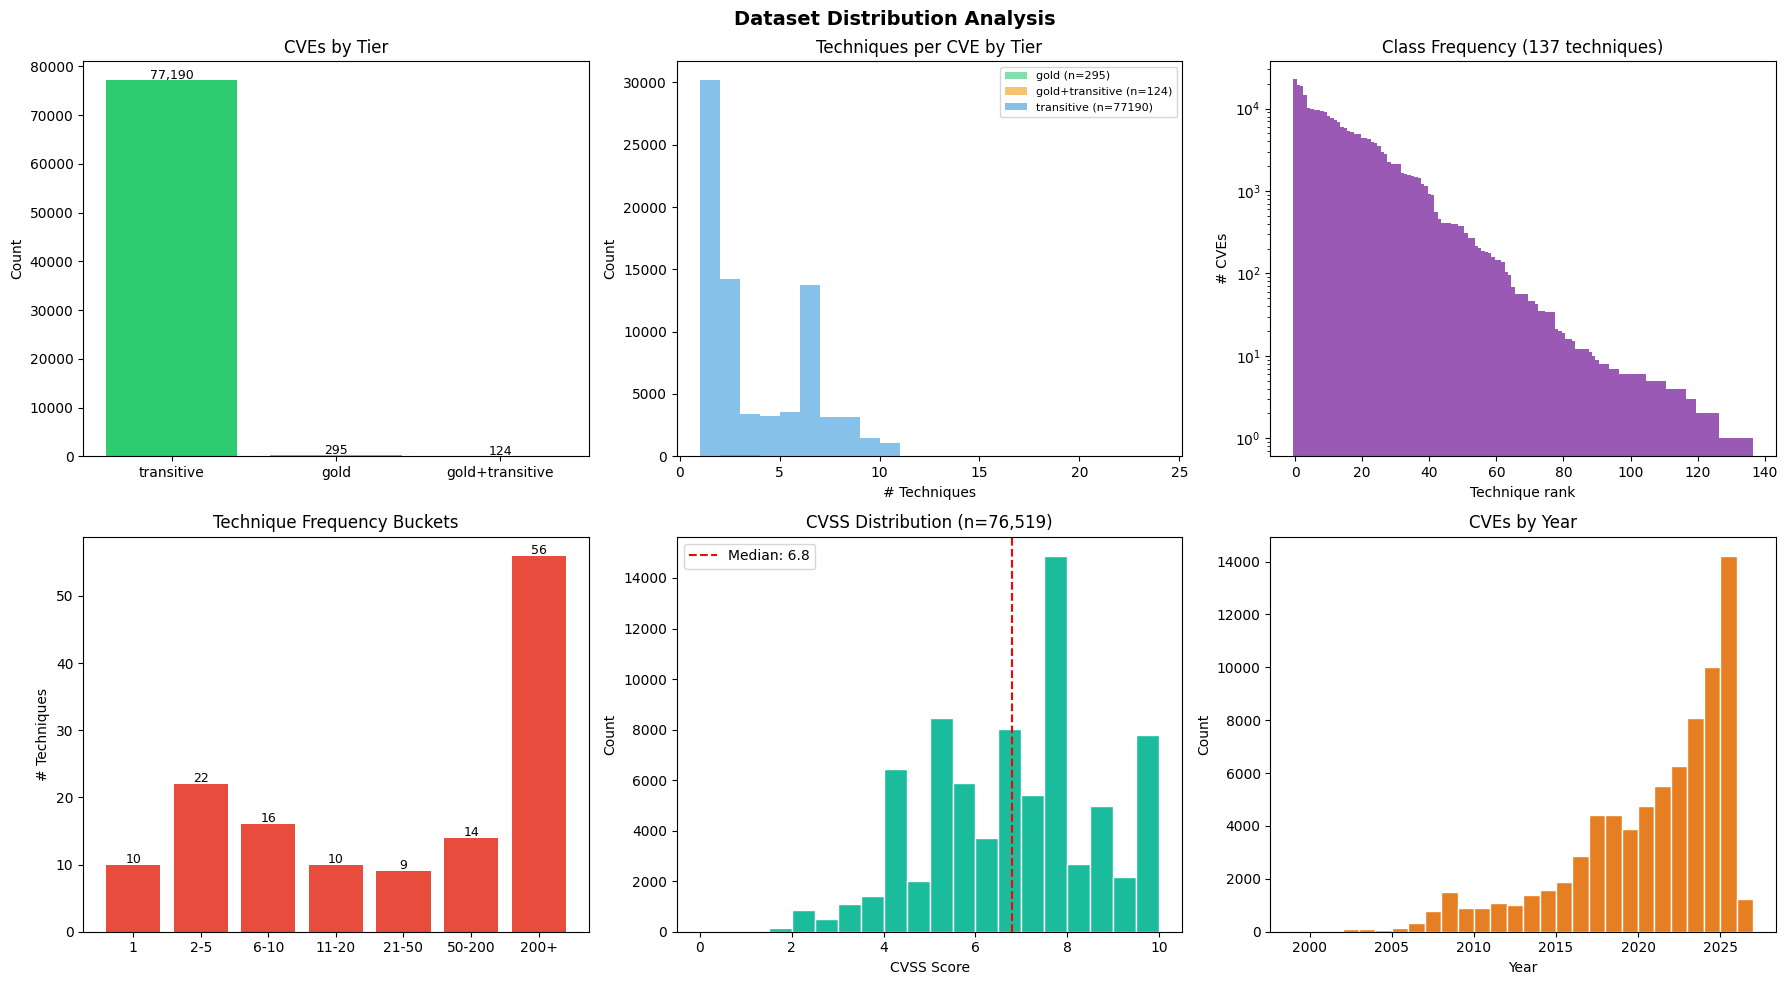


=== Top 10 Most Frequent Techniques ===
  T1027 (Obfuscated Files or Information): 22,711
  T1574 (Hijack Execution Flow): 19,272
  T1550 (Use Alternate Authentication Material): 18,786
  T1083 (File and Directory Discovery): 14,565
  T1562 (Impair Defenses): 10,193
  T1111 (Multi-Factor Authentication Interception): 9,899
  T1082 (System Information Discovery): 9,592
  T1592 (Gather Victim Host Information): 9,498
  T1553 (Subvert Trust Controls): 9,413
  T1135 (Network Share Discovery): 9,227

=== Bottom 10 Rarest Techniques ===
  T1219 (Remote Access Software): 1
  T1569 (System Services): 1
  T1601 (Modify System Image): 1
  T1222 (File and Directory Permissions Modification): 1
  T1484 (Domain or Tenant Policy Modification): 1
  T1489 (Service Stop): 1
  T1571 (Non-Standard Port): 1
  T1653 (Power Settings): 1
  T1570 (Lateral Tool Transfer): 1
  T1199 (Trusted Relationship): 1

Techniques with 0 examples: 66
  ['T1006', 'T1008', 'T1010', 'T1020', 'T1025', 'T1029', 'T1030', 'T105

In [16]:
# Cell 10: Distribution analysis + plots

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Dataset Distribution Analysis", fontsize=14, fontweight="bold")

# 1. Tier distribution
ax = axes[0, 0]
tier_data = dataset_df["tier"].value_counts()
bars = ax.bar(tier_data.index, tier_data.values, color=["#2ecc71", "#f39c12", "#3498db"])
ax.set_title("CVEs by Tier")
ax.set_ylabel("Count")
for bar, val in zip(bars, tier_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            f"{val:,}", ha="center", fontsize=9)

# 2. Techniques per CVE by tier
ax = axes[0, 1]
for tier, color in [("gold", "#2ecc71"), ("gold+transitive", "#f39c12"), ("transitive", "#3498db")]:
    subset = dataset_df[dataset_df["tier"] == tier]["num_techniques"]
    if len(subset) > 0:
        ax.hist(subset, bins=range(1, 25), alpha=0.6, label=f"{tier} (n={len(subset)})", color=color)
ax.set_title("Techniques per CVE by Tier")
ax.set_xlabel("# Techniques")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# 3. Class frequency distribution (how many CVEs per technique)
ax = axes[0, 2]
tech_freq = Counter()
for techs in dataset_df["techniques"]:
    tech_freq.update(techs)
freq_values = sorted(tech_freq.values(), reverse=True)
ax.bar(range(len(freq_values)), freq_values, color="#9b59b6", width=1.0)
ax.set_title(f"Class Frequency ({len(tech_freq)} techniques)")
ax.set_xlabel("Technique rank")
ax.set_ylabel("# CVEs")
ax.set_yscale("log")

# 4. Class frequency buckets
ax = axes[1, 0]
buckets = {"1": 0, "2-5": 0, "6-10": 0, "11-20": 0, "21-50": 0, "50-200": 0, "200+": 0}
for count in tech_freq.values():
    if count == 1: buckets["1"] += 1
    elif count <= 5: buckets["2-5"] += 1
    elif count <= 10: buckets["6-10"] += 1
    elif count <= 20: buckets["11-20"] += 1
    elif count <= 50: buckets["21-50"] += 1
    elif count <= 200: buckets["50-200"] += 1
    else: buckets["200+"] += 1
bars = ax.bar(buckets.keys(), buckets.values(), color="#e74c3c")
ax.set_title("Technique Frequency Buckets")
ax.set_ylabel("# Techniques")
for bar, val in zip(bars, buckets.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
            str(val), ha="center", fontsize=9)

# 5. CVSS distribution
ax = axes[1, 1]
cvss_data = dataset_df["cvss_score"].dropna()
ax.hist(cvss_data, bins=20, color="#1abc9c", edgecolor="white")
ax.set_title(f"CVSS Distribution (n={len(cvss_data):,})")
ax.set_xlabel("CVSS Score")
ax.set_ylabel("Count")
ax.axvline(cvss_data.median(), color="red", linestyle="--", label=f"Median: {cvss_data.median():.1f}")
ax.legend()

# 6. Year distribution
ax = axes[1, 2]
year_data = dataset_df["year"].dropna()
ax.hist(year_data, bins=range(int(year_data.min()), int(year_data.max()) + 2), 
        color="#e67e22", edgecolor="white")
ax.set_title("CVEs by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig("dataset_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top/bottom techniques
print("\n=== Top 10 Most Frequent Techniques ===")
for tid, count in tech_freq.most_common(10):
    print(f"  {tid} ({tech_names.get(tid, '?')}): {count:,}")

print(f"\n=== Bottom 10 Rarest Techniques ===")
for tid, count in tech_freq.most_common()[-10:]:
    print(f"  {tid} ({tech_names.get(tid, '?')}): {count}")

# Techniques with 0 training examples (in our 105 but not in dataset)
missing_techs = set(parent_techniques) - set(tech_freq.keys())
print(f"\nTechniques with 0 examples: {len(missing_techs)}")
if missing_techs:
    print(f"  {sorted(missing_techs)[:20]}")

print("\n✅ Distribution analysis complete.")

In [17]:
# Cell 10b: Refresh label space with filtered dataset

tech_counts = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        if t in tech2idx:
            tech_counts[t] += 1

zero_classes = [t for t in tech2idx if tech_counts.get(t, 0) == 0]
print(f"Classes with 0 samples: {len(zero_classes)}")

if zero_classes:
    active_techs = [t for t in tech2idx if t not in set(zero_classes)]
    tech2idx = {t: i for i, t in enumerate(sorted(active_techs))}
    idx2tech = {i: t for t, i in tech2idx.items()}
    NUM_CLASSES = len(tech2idx)
    print(f"Dropped {len(zero_classes)} empty classes → {NUM_CLASSES} active classes")
else:
    print(f"All {NUM_CLASSES} classes have samples")

# Filter dataset to only include active techniques
dataset_df["techniques"] = dataset_df["techniques"].apply(
    lambda ts: [t for t in ts if t in tech2idx]
)
dataset_df["num_techniques"] = dataset_df["techniques"].apply(len)
dataset_df = dataset_df[dataset_df["num_techniques"] > 0].reset_index(drop=True)

print(f"Final dataset: {len(dataset_df):,} samples, {NUM_CLASSES} classes")
print(f"Labels per sample: mean={dataset_df['num_techniques'].mean():.1f}, median={dataset_df['num_techniques'].median():.0f}")

Classes with 0 samples: 66
Dropped 66 empty classes → 137 active classes
Final dataset: 77,609 samples, 137 classes
Labels per sample: mean=3.3, median=2


In [18]:
# Cell 11: Class weights (log-dampened)

total = len(dataset_df)
tech_counts_final = Counter()
for techs in dataset_df["techniques"]:
    for t in techs:
        tech_counts_final[t] += 1

pos_weights = torch.ones(NUM_CLASSES)
for t, idx in tech2idx.items():
    pos = tech_counts_final.get(t, 1)
    neg = total - pos
    pos_weights[idx] = min(np.log1p(neg / pos), 10.0)

print(f"Weight range: {pos_weights.min():.3f} – {pos_weights.max():.3f}")
print(f"Mean weight: {pos_weights.mean():.3f}")

Weight range: 1.229 – 10.000
Mean weight: 6.663


In [19]:
# Cell 12: Train/Val/Test split (same as before)

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(dataset_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Train: 62,087 | Val: 7,761 | Test: 7,761


In [20]:
# Cell 13: Dataset class using enriched_desc

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

MAX_LEN = 512
MODEL_NAME = "ehsanaghaei/SecureBERT"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class CVEDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, tech2idx, num_classes):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.tech2idx = tech2idx
        self.num_classes = num_classes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row["enriched_desc"]  # <-- ENRICHED description
        encoding = self.tokenizer(
            text, max_length=self.max_len, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        label = torch.zeros(self.num_classes)
        for t in row["techniques"]:
            if t in self.tech2idx:
                label[self.tech2idx[t]] = 1.0
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": label,
        }

train_dataset = CVEDataset(train_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)
val_dataset = CVEDataset(val_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)
test_dataset = CVEDataset(test_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)

print(f"Datasets: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")
print(f"Using enriched descriptions with CVSS prefix")
print(f"Sample input: {train_dataset[0]['input_ids'].shape}")

Datasets: train=62087, val=7761, test=7761
Using enriched descriptions with CVSS prefix
Sample input: torch.Size([512])


In [27]:
# Cell 13b: Dataset WITHOUT CWE in input

class CVEDatasetNoCWE(Dataset):
    def __init__(self, df, tokenizer, max_len, tech2idx, num_classes):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.tech2idx = tech2idx
        self.num_classes = num_classes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Build input: CVSS prefix + description (NO CWE)
        parts = []
        if pd.notna(row.get("attack_vector")):
            parts.append(f"[AV:{row['attack_vector']} "
                        f"AC:{row['attack_complexity']} "
                        f"PR:{row['privileges_required']} "
                        f"UI:{row['user_interaction']} "
                        f"C:{row['conf_impact']} "
                        f"I:{row['integ_impact']} "
                        f"A:{row['avail_impact']}]")
        parts.append(row["description"])
        text = " ".join(parts)
        
        encoding = self.tokenizer(
            text, max_length=self.max_len, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        label = torch.zeros(self.num_classes)
        for t in row["techniques"]:
            if t in self.tech2idx:
                label[self.tech2idx[t]] = 1.0
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": label,
        }

train_dataset = CVEDatasetNoCWE(train_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)
val_dataset = CVEDatasetNoCWE(val_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)
test_dataset = CVEDatasetNoCWE(test_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)

# Verify input format
sample = train_dataset[0]
tokens = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
print(f"Sample input (first 200 chars):\n{tokens[:200]}")
print(f"\nNo CWE in input ✓")
print(f"Datasets: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

Sample input (first 200 chars):
[AV:LOCAL AC:LOW PR:HIGH UI:NONE C:NONE I:HIGH A:NONE] A vulnerability in the CLI of Cisco StarOS operating system for Cisco ASR 5000 Series Routers could allow an authenticated, local attacker to ele

No CWE in input ✓
Datasets: train=62087, val=7761, test=7761


In [28]:
# Cell 14: Model (same as before)

class SecureBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        return self.classifier(cls_output)

In [29]:
# Cell 15: Stable ASL + DataLoaders

BATCH_SIZE = 16
EPOCHS = 10
GRAD_ACCUM_STEPS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=0, pin_memory=False)

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-6):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, labels):
        # Use logsigmoid for numerical stability instead of log(sigmoid())
        probs = torch.sigmoid(logits)
        probs = probs.clamp(self.eps, 1.0 - self.eps)
        
        # Asymmetric clipping on negatives
        probs_neg = (probs + self.clip).clamp(max=1.0 - self.eps)
        
        # Stable log computations
        log_probs = torch.log(probs)
        log_one_minus_probs_neg = torch.log(1.0 - probs_neg)
        
        # Focusing weights
        pos_weight = (1.0 - probs).detach() ** self.gamma_pos  # detach to stabilize
        neg_weight = probs_neg.detach() ** self.gamma_neg
        
        # Loss
        loss_pos = -labels * pos_weight * log_probs
        loss_neg = -(1.0 - labels) * neg_weight * log_one_minus_probs_neg
        
        loss = loss_pos + loss_neg
        
        # Clamp to prevent any NaN propagation
        loss = loss.clamp(max=10.0)
        
        return loss.mean()

criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)
print("✅ Stable ASL ready.")

✅ Stable ASL ready.


In [30]:
# Cell 15b: Rebuild DataLoaders

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=0, pin_memory=False)
print(f"✅ DataLoaders rebuilt (no CWE). Train batches: {len(train_loader)}")

✅ DataLoaders rebuilt (no CWE). Train batches: 3880


In [31]:
# Cell 16: Training WITHOUT mixed precision

model = SecureBERTClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)
LR = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

best_val_micro_f1 = 0
best_epoch = 0
history = {"train_loss": [], "val_loss": [], "val_micro_f1": [], "val_macro_f1": []}

def evaluate_fp32(model, loader, criterion, device, threshold=0.35):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) > threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, micro_f1, macro_f1

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val µF1':>7} | {'Val MF1':>7} | {'Best':>4}")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for step, batch in enumerate(pbar):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels) / GRAD_ACCUM_STEPS
        
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS
        
        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        pbar.set_postfix({"loss": f"{loss.item() * GRAD_ACCUM_STEPS:.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_micro_f1, val_macro_f1 = evaluate_fp32(model, val_loader, criterion, DEVICE)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_micro_f1"].append(val_micro_f1)
    history["val_macro_f1"].append(val_macro_f1)

    is_best = val_micro_f1 > best_val_micro_f1
    if is_best:
        best_val_micro_f1 = val_micro_f1
        best_epoch = epoch + 1
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_micro_f1": val_micro_f1,
            "val_macro_f1": val_macro_f1,
            "tech2idx": tech2idx,
            "idx2tech": idx2tech,
        }, "best_securebert_classifier.pt")

    print(f"{epoch+1:>5} | {avg_train_loss:>10.4f} | {val_loss:>8.4f} | {val_micro_f1:>7.4f} | {val_macro_f1:>7.4f} | {'  ✓' if is_best else ''}")

print(f"\nBest epoch: {best_epoch} (Val µF1={best_val_micro_f1:.4f})")

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\Gouda\Desktop\AI for CS\Project\NVD2ATTCK\venv\Lib\site-packages\huggingface_hub\utils\_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Gouda\Desktop\AI for CS\Project\NVD2ATTCK\venv\Lib\site-packages\httpx\_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/ehsanaghaei/SecureBERT/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Python314\Lib\threading.py", line 1082, in _bootstrap_inner
    self._context.run(self.run)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^
  File "C:\Python314\Lib\threading.py", line 1

Epoch | Train Loss | Val Loss | Val µF1 | Val MF1 | Best
------------------------------------------------------------


    1 |     0.0258 |   0.0116 |  0.3777 |  0.1244 |   ✓


    2 |     0.0110 |   0.0104 |  0.4150 |  0.1566 |   ✓


    3 |     0.0096 |   0.0098 |  0.4732 |  0.1951 |   ✓


...

    6 |     0.0068 |   0.0101 |  0.5564 |  0.2246 |   ✓


    7 |     0.0061 |   0.0105 |  0.5563 |  0.2193 | 


    8 |     0.0055 |   0.0116 |  0.5801 |  0.2264 |   ✓


    9 |     0.0050 |   0.0129 |  0.5804 |  0.2267 |   ✓


   10 |     0.0047 |   0.0132 |  0.5908 |  0.2325 |   ✓

Best epoch: 10 (Val µF1=0.5908)


In [32]:
# Cell 17: Full test evaluation

from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# Load best checkpoint
checkpoint = torch.load("best_securebert_classifier.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val µF1={checkpoint['val_micro_f1']:.4f}, val MF1={checkpoint['val_macro_f1']:.4f})")

# Predict on test set
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"]
        logits = model(input_ids, attention_mask)
        all_logits.append(logits.cpu())
        all_labels.append(labels)

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels).numpy()
all_probs = torch.sigmoid(all_logits).numpy()

# Threshold sweep
print("\n--- Threshold sweep ---")
for t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (all_probs > t).astype(int)
    micro = f1_score(all_labels, preds, average="micro", zero_division=0)
    macro = f1_score(all_labels, preds, average="macro", zero_division=0)
    prec = precision_score(all_labels, preds, average="micro", zero_division=0)
    rec = recall_score(all_labels, preds, average="micro", zero_division=0)
    avg_preds = preds.sum(axis=1).mean()
    print(f"  t={t:.2f} | µF1={micro:.4f} MF1={macro:.4f} | P={prec:.4f} R={rec:.4f} | avg_labels={avg_preds:.1f}")

# Use best threshold
best_t = max([0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
             key=lambda t: f1_score(all_labels, (all_probs > t).astype(int), average="micro", zero_division=0))
print(f"\nBest threshold: {best_t}")

preds = (all_probs > best_t).astype(int)

# Per-class report
tech_names = [idx2tech[i] for i in range(NUM_CLASSES)]
report = classification_report(all_labels, preds, target_names=tech_names, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).T

# Summary
print(f"\n--- Test Results (threshold={best_t}) ---")
print(f"Micro F1:  {report_df.loc['micro avg', 'f1-score']:.4f}")
print(f"Macro F1:  {report_df.loc['macro avg', 'f1-score']:.4f}")
print(f"Weighted F1: {report_df.loc['weighted avg', 'f1-score']:.4f}")
print(f"Samples:   {report_df.loc['samples avg', 'f1-score']:.4f}")

# Top and bottom classes
per_class = report_df.iloc[:-4].copy()  # exclude avg rows
per_class["support"] = per_class["support"].astype(int)
per_class = per_class.sort_values("f1-score", ascending=False)

print(f"\n--- Top 10 classes ---")
for idx, (tech, row) in enumerate(per_class.head(10).iterrows()):
    print(f"  {tech}: F1={row['f1-score']:.3f} P={row['precision']:.3f} R={row['recall']:.3f} (n={row['support']:.0f})")

print(f"\n--- Bottom 10 classes ---")
for idx, (tech, row) in enumerate(per_class.tail(10).iterrows()):
    print(f"  {tech}: F1={row['f1-score']:.3f} P={row['precision']:.3f} R={row['recall']:.3f} (n={row['support']:.0f})")

# Classes with F1 = 0
zero_f1 = per_class[per_class["f1-score"] == 0]
print(f"\nClasses with F1=0: {len(zero_f1)}/{NUM_CLASSES}")

# Tier-level analysis
print(f"\n--- Performance by tier ---")
test_indices = test_df.index.tolist()
for tier in ["gold", "gold+transitive", "silver", "bronze"]:
    mask = test_df["tier"] == tier
    if mask.sum() == 0:
        continue
    tier_idx = mask[mask].index
    # Map to position in test arrays
    pos = [test_df.index.get_loc(i) for i in tier_idx]
    tier_labels = all_labels[pos]
    tier_preds = preds[pos]
    micro = f1_score(tier_labels, tier_preds, average="micro", zero_division=0)
    macro = f1_score(tier_labels, tier_preds, average="macro", zero_division=0)
    print(f"  {tier:20s}: n={len(pos):>5,} | µF1={micro:.4f} MF1={macro:.4f}")

Loaded best model from epoch 10 (val µF1=0.5908, val MF1=0.2325)


Testing: 100%|██████████| 243/243 [02:08<00:00,  1.88it/s]



--- Threshold sweep ---
  t=0.25 | µF1=0.4330 MF1=0.1542 | P=0.2807 R=0.9467 | avg_labels=11.1
  t=0.30 | µF1=0.5231 MF1=0.1991 | P=0.3650 R=0.9228 | avg_labels=8.3
  t=0.35 | µF1=0.5944 MF1=0.2397 | P=0.4442 R=0.8982 | avg_labels=6.6
  t=0.40 | µF1=0.6485 MF1=0.2743 | P=0.5166 R=0.8708 | avg_labels=5.5
  t=0.45 | µF1=0.6909 MF1=0.3013 | P=0.5853 R=0.8431 | avg_labels=4.7
  t=0.50 | µF1=0.7182 MF1=0.3108 | P=0.6459 R=0.8088 | avg_labels=4.1

Best threshold: 0.5

--- Test Results (threshold=0.5) ---
Micro F1:  0.7182
Macro F1:  0.3108
Weighted F1: 0.7195
Samples:   0.7526

--- Top 10 classes ---
  T1218: F1=0.857 P=1.000 R=0.750 (n=4)
  T1027: F1=0.840 P=0.777 R=0.913 (n=2254)
  T1499: F1=0.836 P=0.771 R=0.912 (n=521)
  T1574: F1=0.827 P=0.747 R=0.926 (n=1913)
  T1592: F1=0.802 P=0.754 R=0.856 (n=951)
  T1082: F1=0.801 P=0.752 R=0.856 (n=957)
  T1135: F1=0.786 P=0.740 R=0.840 (n=923)
  T1111: F1=0.785 P=0.729 R=0.851 (n=985)
  T1550: F1=0.776 P=0.701 R=0.868 (n=1896)
  T1211: F1=0.774 

In [33]:
# Cell 18: Extended evaluation metrics

from sklearn.metrics import label_ranking_average_precision_score, label_ranking_loss
from sklearn.metrics import coverage_error

# Already have: all_probs, all_labels, preds (from Cell 17)

# --- 1. Model Coverage ---
# What fraction of the 137 classes does the model actually predict?
predicted_classes = set()
for row in preds:
    predicted_classes.update(np.where(row == 1)[0])
print(f"--- Model Coverage ---")
print(f"Classes predicted at least once: {len(predicted_classes)}/{NUM_CLASSES}")
print(f"Coverage: {len(predicted_classes)/NUM_CLASSES*100:.1f}%")

# Classes with support > 0 that model never predicts
has_support = set(np.where(all_labels.sum(axis=0) > 0)[0])
never_predicted = has_support - predicted_classes
print(f"Classes with test support but never predicted: {len(never_predicted)}")
if never_predicted:
    for idx in sorted(never_predicted):
        sup = int(all_labels[:, idx].sum())
        print(f"  {idx2tech[idx]}: support={sup}")

# --- 2. Error Analysis ---
print(f"\n--- Error Analysis ---")
# Per-sample: exact match, over-prediction, under-prediction
exact_match = 0
over_pred = 0
under_pred = 0
both_error = 0
for i in range(len(preds)):
    p = set(np.where(preds[i] == 1)[0])
    g = set(np.where(all_labels[i] == 1)[0])
    if p == g:
        exact_match += 1
    else:
        fp = p - g  # false positives
        fn = g - p  # false negatives
        if fp and fn:
            both_error += 1
        elif fp:
            over_pred += 1
        elif fn:
            under_pred += 1

total = len(preds)
print(f"Exact match:      {exact_match:>5,} ({exact_match/total*100:.1f}%)")
print(f"Over-prediction:  {over_pred:>5,} ({over_pred/total*100:.1f}%)")
print(f"Under-prediction: {under_pred:>5,} ({under_pred/total*100:.1f}%)")
print(f"Both FP+FN:       {both_error:>5,} ({both_error/total*100:.1f}%)")

# Most common false positives and false negatives
from collections import Counter
fp_counter = Counter()
fn_counter = Counter()
for i in range(len(preds)):
    p = set(np.where(preds[i] == 1)[0])
    g = set(np.where(all_labels[i] == 1)[0])
    for idx in (p - g):
        fp_counter[idx2tech[idx]] += 1
    for idx in (g - p):
        fn_counter[idx2tech[idx]] += 1

print(f"\nTop 10 false positives (predicted but not in label):")
for tech, count in fp_counter.most_common(10):
    print(f"  {tech}: {count}")

print(f"\nTop 10 false negatives (in label but not predicted):")
for tech, count in fn_counter.most_common(10):
    print(f"  {tech}: {count}")

# --- 3. Ranking Metrics ---
print(f"\n--- Ranking Metrics ---")

# Filter to samples that have at least one positive label
mask = all_labels.sum(axis=1) > 0
labels_filtered = all_labels[mask]
probs_filtered = all_probs[mask]

# LRAP (Label Ranking Average Precision)
lrap = label_ranking_average_precision_score(labels_filtered, probs_filtered)
print(f"LRAP (Label Ranking Avg Precision): {lrap:.4f}")

# Label Ranking Loss (lower is better)
lr_loss = label_ranking_loss(labels_filtered, probs_filtered)
print(f"Label Ranking Loss: {lr_loss:.6f}")

# Coverage Error (lower is better, min = avg number of labels)
cov_err = coverage_error(labels_filtered, probs_filtered)
print(f"Coverage Error: {cov_err:.2f} (ideal ≈ {labels_filtered.sum(axis=1).mean():.1f})")

# --- 4. Recall@K ---
print(f"\n--- Recall@K ---")
for k in [1, 3, 5, 10]:
    recall_at_k = 0
    for i in range(len(probs_filtered)):
        true_labels = set(np.where(labels_filtered[i] == 1)[0])
        if not true_labels:
            continue
        top_k = set(np.argsort(probs_filtered[i])[-k:])
        recall_at_k += len(true_labels & top_k) / len(true_labels)
    recall_at_k /= len(probs_filtered)
    print(f"  R@{k}: {recall_at_k:.4f}")

# --- 5. Per-tier ranking metrics ---
print(f"\n--- LRAP by tier ---")
test_df_reset = test_df.reset_index(drop=True)
for tier in ["gold", "gold+transitive", "silver", "bronze"]:
    tier_mask = test_df_reset["tier"] == tier
    if tier_mask.sum() == 0:
        continue
    tier_labels = all_labels[tier_mask.values]
    tier_probs = all_probs[tier_mask.values]
    # Filter out zero-label rows
    has_label = tier_labels.sum(axis=1) > 0
    if has_label.sum() == 0:
        continue
    tier_lrap = label_ranking_average_precision_score(tier_labels[has_label], tier_probs[has_label])
    tier_lr_loss = label_ranking_loss(tier_labels[has_label], tier_probs[has_label])
    print(f"  {tier:20s}: n={has_label.sum():>5,} | LRAP={tier_lrap:.4f} | RankLoss={tier_lr_loss:.6f}")

# --- Summary ---
print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"{'='*50}")
print(f"Micro F1:    {f1_score(all_labels, preds, average='micro', zero_division=0):.4f}")
print(f"Macro F1:    {f1_score(all_labels, preds, average='macro', zero_division=0):.4f}")
print(f"LRAP:        {lrap:.4f}")
print(f"R@5:         {recall_at_k:.4f}")  # last k=10, need to recalc
print(f"Rank Loss:   {lr_loss:.6f}")
print(f"Coverage:    {len(predicted_classes)}/{NUM_CLASSES} ({len(predicted_classes)/NUM_CLASSES*100:.1f}%)")
print(f"Exact Match: {exact_match/total*100:.1f}%")

--- Model Coverage ---
Classes predicted at least once: 80/137
Coverage: 58.4%
Classes with test support but never predicted: 10
  T1011: support=2
  T1041: support=1
  T1091: support=1
  T1092: support=1
  T1106: support=1
  T1136: support=1
  T1486: support=1
  T1496: support=3
  T1531: support=1
  T1600: support=2

--- Error Analysis ---
Exact match:      4,460 (57.5%)
Over-prediction:  1,603 (20.7%)
Under-prediction:   115 (1.5%)
Both FP+FN:       1,583 (20.4%)

Top 10 false positives (predicted but not in label):
  T1550: 702
  T1083: 612
  T1574: 600
  T1027: 590
  T1553: 541
  T1562: 505
  T1036: 440
  T1539: 395
  T1543: 385
  T1505: 373

Top 10 false negatives (in label but not predicted):
  T1550: 250
  T1083: 215
  T1027: 196
  T1543: 188
  T1553: 176
  T1036: 153
  T1562: 151
  T1135: 148
  T1111: 147
  T1539: 144

--- Ranking Metrics ---
LRAP (Label Ranking Avg Precision): 0.8320
Label Ranking Loss: 0.015867
Coverage Error: 6.33 (ideal ≈ 3.3)

--- Recall@K ---
  R@1: 0.442

In [34]:
# Cell 19: Template memorization test

# Q1: Do all samples with the same CWE set get the same prediction?
from collections import defaultdict

cwe_to_preds = defaultdict(list)
test_df_reset = test_df.reset_index(drop=True)

for i in range(len(preds)):
    cwes = tuple(sorted(test_df_reset.iloc[i]["cwes"]))
    pred_techs = tuple(sorted(np.where(preds[i] == 1)[0]))
    cwe_to_preds[cwes].append(pred_techs)

# Check how many CWE groups have identical predictions
identical = 0
total_groups = 0
for cwes, pred_list in cwe_to_preds.items():
    if len(pred_list) < 2:
        continue
    total_groups += 1
    if len(set(pred_list)) == 1:
        identical += 1

print(f"CWE groups with 2+ samples: {total_groups}")
print(f"Groups with identical predictions: {identical} ({identical/max(total_groups,1)*100:.1f}%)")

# Q2: What happens if we REMOVE the CWE from the input?
# Test a few samples with and without CWE prefix
model.eval()
sample_indices = [0, 100, 500, 1000, 2000]

print(f"\n--- CWE removal test ---")
for idx in sample_indices:
    row = test_df_reset.iloc[idx]
    
    # With CWE (enriched_desc)
    text_with = row["enriched_desc"]
    enc_with = tokenizer(text_with, max_length=512, padding="max_length", 
                         truncation=True, return_tensors="pt")
    
    # Without CWE — strip the prefix
    desc_only = row["description"]
    # Add CVSS but no CWE
    cvss_prefix = text_with.split("|")[0] + "] " if "|" in text_with else ""
    text_without = cvss_prefix + desc_only if cvss_prefix else desc_only
    enc_without = tokenizer(text_without, max_length=512, padding="max_length",
                            truncation=True, return_tensors="pt")
    
    with torch.no_grad():
        logits_with = model(enc_with["input_ids"].to(DEVICE), enc_with["attention_mask"].to(DEVICE))
        logits_without = model(enc_without["input_ids"].to(DEVICE), enc_without["attention_mask"].to(DEVICE))
    
    probs_with = torch.sigmoid(logits_with).cpu().numpy()[0]
    probs_without = torch.sigmoid(logits_without).cpu().numpy()[0]
    
    preds_with = set(np.where(probs_with > 0.5)[0])
    preds_without = set(np.where(probs_without > 0.5)[0])
    
    true_labels = set(np.where(all_labels[idx] == 1)[0])
    
    techs_with = sorted([idx2tech[i] for i in preds_with])
    techs_without = sorted([idx2tech[i] for i in preds_without])
    techs_true = sorted([idx2tech[i] for i in true_labels])
    
    changed = "CHANGED" if preds_with != preds_without else "SAME"
    print(f"\n{row['cve_id']} | CWEs: {row['cwes']}")
    print(f"  True:        {techs_true}")
    print(f"  With CWE:    {techs_with}")
    print(f"  Without CWE: {techs_without} [{changed}]")

CWE groups with 2+ samples: 303
Groups with identical predictions: 34 (11.2%)

--- CWE removal test ---

CVE-2021-24376 | CWEs: ['CWE-434', 'CWE-434']
  True:        ['T1574']
  With CWE:    ['T1574']
  Without CWE: ['T1574'] [SAME]

CVE-2024-39917 | CWEs: ['CWE-307', 'CWE-307']
  True:        ['T1078', 'T1110', 'T1558']
  With CWE:    ['T1078', 'T1110', 'T1558']
  Without CWE: ['T1078', 'T1110', 'T1558'] [SAME]

CVE-2023-47180 | CWEs: ['CWE-862']
  True:        ['T1211']
  With CWE:    ['T1211']
  Without CWE: ['T1211', 'T1542', 'T1556'] [CHANGED]

CVE-2026-0575 | CWEs: ['CWE-74', 'CWE-89']
  True:        ['T1027']
  With CWE:    ['T1027']
  Without CWE: ['T1027', 'T1562', 'T1574'] [CHANGED]

CVE-2018-16720 | CWEs: ['CWE-20']
  True:        ['T1027', 'T1036', 'T1539', 'T1553', 'T1562', 'T1574']
  With CWE:    ['T1027', 'T1036', 'T1539', 'T1553', 'T1562', 'T1574']
  Without CWE: ['T1027', 'T1036', 'T1539', 'T1553', 'T1562', 'T1574'] [SAME]


In [36]:
# Save dataset + metadata for Kaggle

import pickle

# Save the dataframes
train_df.to_parquet("train_df.parquet")
val_df.to_parquet("val_df.parquet")
test_df.to_parquet("test_df.parquet")

# Save metadata
metadata = {
    "tech2idx": tech2idx,
    "idx2tech": idx2tech,
    "NUM_CLASSES": NUM_CLASSES,
    "pos_weights": pos_weights,
    "MODEL_NAME": MODEL_NAME,
    "MAX_LEN": MAX_LEN,
}
with open("dataset_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)

# Save current best model as baseline
import shutil
shutil.copy("best_securebert_classifier.pt", "baseline_model.pt")

print(f"Saved: train_df ({len(train_df):,}), val_df ({len(val_df):,}), test_df ({len(test_df):,})")
print(f"Saved: dataset_metadata.pkl, baseline_model.pt")
print(f"Upload these 5 files to Kaggle.")

Saved: train_df (62,087), val_df (7,761), test_df (7,761)
Saved: dataset_metadata.pkl, baseline_model.pt
Upload these 5 files to Kaggle.


In [24]:
# Cell 16-gold: Training with gold sample upweighting

class CVEDatasetWeighted(Dataset):
    """Same as CVEDatasetNoCWE but returns sample weight based on tier"""
    def __init__(self, df, tokenizer, max_len, tech2idx, num_classes):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.tech2idx = tech2idx
        self.num_classes = num_classes
        
        # Tier weights: gold matters 50x more
        self.tier_weights = {
            "gold": 50.0,
            "gold+transitive": 25.0,
            "transitive": 1.0,            
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        parts = []
        if pd.notna(row.get("attack_vector")):
            parts.append(f"[AV:{row['attack_vector']} "
                        f"AC:{row['attack_complexity']} "
                        f"PR:{row['privileges_required']} "
                        f"UI:{row['user_interaction']} "
                        f"C:{row['conf_impact']} "
                        f"I:{row['integ_impact']} "
                        f"A:{row['avail_impact']}]")
        parts.append(row["description"])
        text = " ".join(parts)
        
        encoding = self.tokenizer(
            text, max_length=self.max_len, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        label = torch.zeros(self.num_classes)
        for t in row["techniques"]:
            if t in self.tech2idx:
                label[self.tech2idx[t]] = 1.0
        
        weight = self.tier_weights.get(row["tier"], 1.0)
        
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": label,
            "weight": torch.tensor(weight, dtype=torch.float32),
        }


MAX_LEN = 512
MODEL_NAME = "ehsanaghaei/SecureBERT_Plus"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)# Rebuild datasets and loaders
train_dataset = CVEDatasetWeighted(train_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)
val_dataset = CVEDatasetWeighted(val_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)
test_dataset = CVEDatasetWeighted(test_df, tokenizer, MAX_LEN, tech2idx, NUM_CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=0, pin_memory=False)

# Weighted ASL
class WeightedAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-6):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, labels, sample_weights=None):
        probs = torch.sigmoid(logits).clamp(self.eps, 1.0 - self.eps)
        probs_neg = (probs + self.clip).clamp(max=1.0 - self.eps)
        
        log_probs = torch.log(probs)
        log_one_minus_probs_neg = torch.log(1.0 - probs_neg)
        
        pos_weight = (1.0 - probs).detach() ** self.gamma_pos
        neg_weight = probs_neg.detach() ** self.gamma_neg
        
        loss_pos = -labels * pos_weight * log_probs
        loss_neg = -(1.0 - labels) * neg_weight * log_one_minus_probs_neg
        
        loss = (loss_pos + loss_neg).clamp(max=10.0)
        
        # Apply per-sample weights
        if sample_weights is not None:
            loss = loss * sample_weights.unsqueeze(1)
        
        return loss.mean()

criterion = WeightedAsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)

# Train
model = SecureBERTClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)
LR = 2e-5
EPOCHS = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

best_val_micro_f1 = 0
best_epoch = 0

def evaluate_weighted(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)  # unweighted for val
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) > threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, micro_f1, macro_f1

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val µF1':>7} | {'Val MF1':>7} | {'Best':>4}")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    
    for step, batch in enumerate(pbar):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        weights = batch["weight"].to(DEVICE)
        
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels, weights) / GRAD_ACCUM_STEPS
        
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS
        
        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        pbar.set_postfix({"loss": f"{loss.item() * GRAD_ACCUM_STEPS:.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_micro_f1, val_macro_f1 = evaluate_weighted(model, val_loader, criterion, DEVICE)

    is_best = val_micro_f1 > best_val_micro_f1
    if is_best:
        best_val_micro_f1 = val_micro_f1
        best_epoch = epoch + 1
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_micro_f1": val_micro_f1,
            "val_macro_f1": val_macro_f1,
            "tech2idx": tech2idx,
            "idx2tech": idx2tech,
            "approach": "gold_upweighted",
        }, "best_gold_upweighted.pt")

    print(f"{epoch+1:>5} | {avg_train_loss:>10.4f} | {val_loss:>8.4f} | {val_micro_f1:>7.4f} | {val_macro_f1:>7.4f} | {'  ✓' if is_best else ''}")

print(f"\nBest epoch: {best_epoch} (Val µF1={best_val_micro_f1:.4f})")

NameError: name 'SecureBERTClassifier' is not defined

In [42]:
import pandas as pd
import pickle

# Load
df = pd.read_parquet("cve_attack_dataset.parquet")
with open("dataset_metadata.pkl", "rb") as f:
    meta = pickle.load(f)

idx2tech = meta["idx2tech"]

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Tiers: {df['tier'].value_counts().to_dict()}")
print(f"Classes: {meta['NUM_CLASSES']}")
print()

# Show 3 samples from each tier
for tier in df["tier"].unique():
    print(f"{'='*60}")
    print(f"TIER: {tier}")
    print(f"{'='*60}")
    subset = df[df["tier"] == tier].sample(min(3, len(df[df["tier"] == tier])), random_state=42)
    for _, row in subset.iterrows():
        labels = [idx2tech[i] for i, v in enumerate(row["techniques"]) if v == 1]
        print(f"\nCVE: {row['cve_id']}")
        print(f"Text: {row['description'][:200]}...")
        print(f"Labels ({len(labels)}): {labels}")
    print()

Shape: (77609, 9)
Columns: ['cve_id', 'description', 'cwes', 'techniques', 'num_techniques', 'tier', 'noisy', 'cvss_score', 'year']
Tiers: {'transitive': 77190, 'gold': 295, 'gold+transitive': 124}
Classes: 137

TIER: transitive

CVE: CVE-2018-0868
Text: Windows Installer in Microsoft Windows Server 2008 SP2 and R2 SP1, Windows 7 SP1, Windows 8.1 and RT 8.1, Windows Server 2012 and R2, Windows 10 Gold, 1511, 1607, 1703, and 1709, Windows Server 2016 a...
Labels (0): []

CVE: CVE-2022-28695
Text: On F5 BIG-IP AFM 16.1.x versions prior to 16.1.2.2, 15.1.x versions prior to 15.1.5.1, 14.1.x versions prior to 14.1.4.6, and 13.1.x versions prior to 13.1.5, an authenticated attacker with high privi...
Labels (0): []

CVE: CVE-2013-3581
Text: ajax.cgi in the web interface on the Choice Wireless Green Packet WIXFMR-111 4G WiMax modem allows remote attackers to obtain sensitive information via an Ajax (1) wmxState or (2) netState request....
Labels (0): []

TIER: gold

CVE: CVE-2025-42599
Text:

In [24]:
# Cell 16: Training loop

from torch.cuda.amp import autocast, GradScaler

model = SecureBERTClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)
LR = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
scaler = GradScaler()

def evaluate(model, loader, criterion, device, threshold=0.35):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            with autocast():
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) > threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, micro_f1, macro_f1

best_val_micro_f1 = 0
best_epoch = 0
history = {"train_loss": [], "val_loss": [], "val_micro_f1": [], "val_macro_f1": []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val µF1':>7} | {'Val MF1':>7} | {'Best':>4}")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for step, batch in enumerate(pbar):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        with autocast():
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss = loss / GRAD_ACCUM_STEPS
        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS
        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        pbar.set_postfix({"loss": f"{loss.item() * GRAD_ACCUM_STEPS:.4f}"})

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_micro_f1, val_macro_f1 = evaluate(model, val_loader, criterion, DEVICE)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_micro_f1"].append(val_micro_f1)
    history["val_macro_f1"].append(val_macro_f1)

    is_best = val_micro_f1 > best_val_micro_f1
    if is_best:
        best_val_micro_f1 = val_micro_f1
        best_epoch = epoch + 1
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_micro_f1": val_micro_f1,
            "val_macro_f1": val_macro_f1,
            "tech2idx": tech2idx,
            "idx2tech": idx2tech,
        }, "best_securebert_classifier.pt")

    print(f"{epoch+1:>5} | {avg_train_loss:>10.4f} | {val_loss:>8.4f} | {val_micro_f1:>7.4f} | {val_macro_f1:>7.4f} | {'  ✓' if is_best else ''}")

print(f"\nBest epoch: {best_epoch} (Val µF1={best_val_micro_f1:.4f})")

Exception in thread Thread-auto_conversion:
Loading weights:  52%|█████▏    | 102/197 [00:00<00:00, 679.01it/s, Materializing param=encoder.layer.6.attention.output.LayerNorm.bias]  File "c:\Users\Gouda\Desktop\AI for CS\Project\NVD2ATTCK\venv\Lib\site-packages\huggingface_hub\utils\_http.py", line 657, in hf_raise_for_status
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Gouda\Desktop\AI for CS\Project\NVD2ATTCK\venv\Lib\site-packages\httpx\_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/ehsanaghaei/SecureBERT/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
Loading weights:  52%|█████▏    | 102/197 [00:00<00:00, 679.01it/s, Materializin

Epoch | Train Loss | Val Loss | Val µF1 | Val MF1 | Best
------------------------------------------------------------


    1 |        nan |      nan |  0.4291 |  0.2425 |   ✓


    2 |        nan |      nan |  0.4087 |  0.2284 | 


    3 |        nan |      nan |  0.4072 |  0.2276 | 


    4 |        nan |      nan |  0.4062 |  0.2273 | 


    5 |        nan |      nan |  0.0000 |  0.0000 | 


KeyboardInterrupt: 

In [19]:
# Data Quality Audit — run while training continues

import numpy as np
from collections import Counter

print("=" * 60)
print("DATA QUALITY AUDIT")
print("=" * 60)

# 1. Label density
labels_per_sample = dataset_df["techniques"].apply(len)
print(f"\n--- Labels per sample ---")
print(f"Mean: {labels_per_sample.mean():.1f}, Median: {labels_per_sample.median():.0f}")
print(f"Min: {labels_per_sample.min()}, Max: {labels_per_sample.max()}")
print(f"Samples with 1 label: {(labels_per_sample == 1).sum():,}")
print(f"Samples with >10 labels: {(labels_per_sample > 10).sum():,}")
print(f"Samples with >20 labels: {(labels_per_sample > 20).sum():,}")

# 2. Tier breakdown with label stats
print(f"\n--- Per-tier stats ---")
for tier in dataset_df["tier"].unique():
    sub = dataset_df[dataset_df["tier"] == tier]
    lps = sub["techniques"].apply(len)
    print(f"  {tier}: {len(sub):,} samples, avg labels={lps.mean():.1f}, median={lps.median():.0f}")

# 3. Description length
desc_lengths = dataset_df["description"].str.len()
desc_words = dataset_df["description"].str.split().apply(len)
print(f"\n--- Description length ---")
print(f"Chars: mean={desc_lengths.mean():.0f}, median={desc_lengths.median():.0f}, min={desc_lengths.min()}, max={desc_lengths.max()}")
print(f"Words: mean={desc_words.mean():.0f}, median={desc_words.median():.0f}")
print(f"Descriptions < 20 words: {(desc_words < 20).sum():,}")
print(f"Descriptions < 10 words: {(desc_words < 10).sum():,}")

# 4. Noisy label stats
print(f"\n--- Noisy labels ---")
print(f"Noisy=True: {dataset_df['noisy'].sum():,} ({dataset_df['noisy'].mean()*100:.1f}%)")

# 5. Sample some transitive-only labels
print(f"\n--- Sample transitive-only CVEs (most common tier) ---")
trans = dataset_df[dataset_df["tier"] == "transitive"].sample(5, random_state=42)
for _, row in trans.iterrows():
    techs = row["techniques"]
    desc_preview = row["description"][:120]
    print(f"\n  {row['cve_id']} | {len(techs)} labels | noisy={row['noisy']}")
    print(f"  Desc: {desc_preview}...")
    print(f"  Techs: {techs[:5]}{'...' if len(techs) > 5 else ''}")

# 6. Check for duplicate descriptions
print(f"\n--- Duplicates ---")
n_unique_desc = dataset_df["description"].nunique()
print(f"Unique descriptions: {n_unique_desc:,} / {len(dataset_df):,}")
print(f"Duplicate descriptions: {len(dataset_df) - n_unique_desc:,}")

# 7. Label co-occurrence — are certain labels ALWAYS together?
print(f"\n--- Top 10 label pairs (co-occurrence) ---")
pair_counts = Counter()
for techs in dataset_df["techniques"]:
    techs_sorted = sorted(techs)
    for i in range(len(techs_sorted)):
        for j in range(i+1, min(i+5, len(techs_sorted))):  # limit pairs
            pair_counts[(techs_sorted[i], techs_sorted[j])] += 1
for (a, b), count in pair_counts.most_common(10):
    na = tech_names.get(a, "?")[:25]
    nb = tech_names.get(b, "?")[:25]
    print(f"  {a} ({na}) + {b} ({nb}): {count:,}")

DATA QUALITY AUDIT

--- Labels per sample ---
Mean: 7.0, Median: 4
Min: 1, Max: 48
Samples with 1 label: 12,782
Samples with >10 labels: 14,154
Samples with >20 labels: 9,570

--- Per-tier stats ---
  transitive: 77,190 samples, avg labels=7.0, median=4
  gold: 295 samples, avg labels=2.7, median=2
  gold+transitive: 124 samples, avg labels=2.9, median=2

--- Description length ---
Chars: mean=328, median=266, min=17, max=3998
Words: mean=48, median=39
Descriptions < 20 words: 7,295
Descriptions < 10 words: 1,379

--- Noisy labels ---
Noisy=True: 21,955 (28.3%)

--- Sample transitive-only CVEs (most common tier) ---

  CVE-2018-0868 | 6 labels | noisy=False
  Desc: Windows Installer in Microsoft Windows Server 2008 SP2 and R2 SP1, Windows 7 SP1, Windows 8.1 and RT 8.1, Windows Server...
  Techs: ['T1027', 'T1036', 'T1539', 'T1553', 'T1562']...

  CVE-2022-28695 | 6 labels | noisy=False
  Desc: On F5 BIG-IP AFM 16.1.x versions prior to 16.1.2.2, 15.1.x versions prior to 15.1.5.1, 14.1.x

In [20]:
# How templated are the labels?

label_sets = dataset_df["techniques"].apply(lambda x: tuple(sorted(x)))
unique_label_sets = label_sets.nunique()
print(f"Unique label sets: {unique_label_sets} / {len(dataset_df):,} samples")
print(f"Ratio: {unique_label_sets/len(dataset_df)*100:.1f}%")

# Top 10 most common label sets
from collections import Counter
label_set_counts = Counter(label_sets)
print(f"\nTop 10 most common label sets:")
for ls, count in label_set_counts.most_common(10):
    names = [f"{t}({tech_names.get(t,'?')[:20]})" for t in ls[:4]]
    print(f"  {count:>6,}x | {len(ls)} labels | {', '.join(names)}{'...' if len(ls)>4 else ''}")

# How many samples share the top label set?
top_count = label_set_counts.most_common(1)[0][1]
print(f"\nMost common label set covers: {top_count:,} / {len(dataset_df):,} = {top_count/len(dataset_df)*100:.1f}%")

# Gold vs transitive label diversity
for tier in ["gold", "gold+transitive", "transitive"]:
    sub = dataset_df[dataset_df["tier"] == tier]
    sub_sets = sub["techniques"].apply(lambda x: tuple(sorted(x)))
    print(f"\n{tier}: {sub_sets.nunique()} unique label sets / {len(sub)} samples")

# Check: do CVEs with same CWE always get same labels?
# We need to check if CWE is driving the templating
print(f"\n--- CWE-driven templating check ---")
# Get CWEs from the dataset if available
if "cwes" in dataset_df.columns:
    cwe_label_map = {}
    for _, row in dataset_df.iterrows():
        for cwe in row["cwes"]:
            key = cwe
            val = tuple(sorted(row["techniques"]))
            if key not in cwe_label_map:
                cwe_label_map[key] = set()
            cwe_label_map[key].add(val)
    
    single_set_cwes = sum(1 for v in cwe_label_map.values() if len(v) == 1)
    print(f"CWEs that always produce same label set: {single_set_cwes} / {len(cwe_label_map)}")
else:
    print("No 'cwes' column — check how labels were assigned in Cell 9")
    

Unique label sets: 756 / 77,609 samples
Ratio: 1.0%

Top 10 most common label sets:
  11,415x | 6 labels | T1027(Obfuscated Files or ), T1036(Masquerading), T1539(Steal Web Session Co), T1553(Subvert Trust Contro)...
   8,948x | 25 labels | T1007(System Service Disco), T1016(System Network Confi), T1018(Remote System Discov), T1033(System Owner/User Di)...
   6,623x | 3 labels | T1211(Exploitation for Def), T1542(Pre-OS Boot), T1556(Modify Authenticatio)
   5,518x | 2 labels | T1027(Obfuscated Files or ), T1564(Hide Artifacts)
   5,489x | 1 labels | T1574(Hijack Execution Flo)
   4,182x | 3 labels | T1027(Obfuscated Files or ), T1562(Impair Defenses), T1574(Hijack Execution Flo)
   3,881x | 13 labels | T1014(Rootkit), T1027(Obfuscated Files or ), T1037(Boot or Logon Initia), T1080(Taint Shared Content)...
   3,673x | 8 labels | T1040(Network Sniffing), T1134(Access Token Manipul), T1185(Browser Session Hija), T1505(Server Software Comp)...
   3,511x | 1 labels | T1499(Endpoint Denial o

In [21]:
# Cell 9b: Enrich descriptions with structured features
# Run this AFTER Cell 9, BEFORE Cell 10

def enrich_description(row):
    parts = []
    
    # Original description
    parts.append(row["description"])
    
    # CWE info
    if "cwes" in row and row["cwes"]:
        cwe_str = ", ".join(row["cwes"][:5])
        parts.append(f"[CWE: {cwe_str}]")
    
    # CVSS vector if available
    if "cvss_vector" in row and pd.notna(row.get("cvss_vector")):
        parts.append(f"[CVSS: {row['cvss_vector']}]")
    
    # CVSS score if available  
    if "cvss_score" in row and pd.notna(row.get("cvss_score")):
        parts.append(f"[Score: {row['cvss_score']}]")
    
    # Attack vector if available
    if "attack_vector" in row and pd.notna(row.get("attack_vector")):
        parts.append(f"[Vector: {row['attack_vector']}]")
    
    return " ".join(parts)

# Check what columns we actually have
print(f"Available columns: {list(dataset_df.columns)}")

Available columns: ['cve_id', 'description', 'cwes', 'techniques', 'num_techniques', 'tier', 'noisy', 'cvss_score', 'year']


In [21]:
# Audit: What CVSS data is in the NVD JSON files?

import json, os, glob

nvd_dir = "OSRs/NVD"  # adjust if different
nvd_files = glob.glob(os.path.join(nvd_dir, "nvdcve-2.0-*.json"))
if not nvd_files:
    nvd_files = glob.glob(os.path.join(nvd_dir, "nvdcve*.json"))
if not nvd_files:
    nvd_files = glob.glob("nvdcve*.json")

print(f"NVD files found: {len(nvd_files)}")

# Grab first CVE with CVSS data
sample_cve = None
for f in sorted(nvd_files)[:1]:
    with open(f, encoding="utf-8") as fh:
        data = json.load(fh)
    for item in data.get("vulnerabilities", data.get("CVE_Items", []))[:50]:
        cve = item.get("cve", item)
        # NVD 2.0 format
        if "metrics" in cve:
            if cve["metrics"]:
                sample_cve = cve
                break
        # NVD 1.0 format
        elif "impact" in item:
            if item["impact"]:
                sample_cve = item
                break

if sample_cve:
    print("\n--- Sample CVE structure (metrics/impact section) ---")
    # Try NVD 2.0
    if "metrics" in sample_cve:
        metrics = sample_cve["metrics"]
        print(f"Metric keys: {list(metrics.keys())}")
        for key, val in metrics.items():
            if isinstance(val, list) and len(val) > 0:
                entry = val[0]
                if "cvssData" in entry:
                    cvss = entry["cvssData"]
                    print(f"\n{key}:")
                    for k, v in cvss.items():
                        print(f"  {k}: {v}")
                elif "cvssV2" in entry:
                    cvss = entry["cvssV2"]
                    print(f"\n{key}:")
                    for k, v in cvss.items():
                        if not isinstance(v, dict):
                            print(f"  {k}: {v}")
    # Try NVD 1.0
    elif "impact" in sample_cve:
        impact = sample_cve["impact"]
        print(f"Impact keys: {list(impact.keys())}")
        print(json.dumps(impact, indent=2)[:2000])
else:
    print("No CVE with metrics found — check file format")
    # Show raw structure
    for f in sorted(nvd_files)[:1]:
        with open(f, encoding="utf-8") as fh:
            data = json.load(fh)
        print(f"Top-level keys: {list(data.keys())}")
        items = data.get("vulnerabilities", data.get("CVE_Items", []))
        if items:
            print(f"First item keys: {list(items[0].keys())}")
            print(json.dumps(items[0], indent=2)[:3000])

NVD files found: 25

--- Sample CVE structure (metrics/impact section) ---
Metric keys: ['cvssMetricV2']

cvssMetricV2:
  version: 2.0
  vectorString: AV:N/AC:L/Au:N/C:C/I:C/A:C
  baseScore: 10.0
  accessVector: NETWORK
  accessComplexity: LOW
  authentication: NONE
  confidentialityImpact: COMPLETE
  integrityImpact: COMPLETE
  availabilityImpact: COMPLETE


In [22]:
# Cell 13: PyTorch Dataset class + load tokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

class CVEDataset(Dataset):
    def __init__(self, df, tokenizer, tech2idx, num_classes, max_length=MAX_LENGTH):
        self.descriptions = df["description"].tolist()
        self.techniques_list = df["techniques"].tolist()
        self.tiers = df["tier"].tolist()
        self.noisy = df["noisy"].tolist()
        self.tokenizer = tokenizer
        self.tech2idx = tech2idx
        self.num_classes = num_classes
        self.max_length = max_length
    
    def __len__(self):
        return len(self.descriptions)
    
    def __getitem__(self, idx):
        # Tokenize
        encoding = self.tokenizer(
            self.descriptions[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        
        # Multi-hot label vector
        labels = torch.zeros(self.num_classes, dtype=torch.float32)
        for t in self.techniques_list[idx]:
            if t in self.tech2idx:
                labels[self.tech2idx[t]] = 1.0
        
        # Sample weight (tier-based)
        tier = self.tiers[idx]
        weight = TIER_WEIGHTS.get(tier, 0.2)
        if self.noisy[idx]:
            weight *= 0.5
        
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels,
            "sample_weight": torch.tensor(weight, dtype=torch.float32),
        }

# Quick test
train_dataset = CVEDataset(train_df, tokenizer, tech2idx, NUM_CLASSES)
val_dataset   = CVEDataset(val_df, tokenizer, tech2idx, NUM_CLASSES)
test_dataset  = CVEDataset(test_df, tokenizer, tech2idx, NUM_CLASSES)

sample = train_dataset[0]
print(f"\nSample shapes:")
print(f"  input_ids:     {sample['input_ids'].shape}")
print(f"  attention_mask: {sample['attention_mask'].shape}")
print(f"  labels:        {sample['labels'].shape} (sum={sample['labels'].sum().item():.0f})")
print(f"  sample_weight: {sample['sample_weight'].item():.2f}")

print(f"\nDataset sizes: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")
print("✅ Datasets created.")

Tokenizer loaded: ehsanaghaei/SecureBERT_Plus

Sample shapes:
  input_ids:     torch.Size([256])
  attention_mask: torch.Size([256])
  labels:        torch.Size([137]) (sum=5)
  sample_weight: 0.20

Dataset sizes: train=62087, val=7761, test=7761
✅ Datasets created.


In [16]:
# Cell 14: Model definition (SecureBERT encoder + linear classifier head)

class SecureBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.encoder.gradient_checkpointing_enable()  # save VRAM
        hidden_size = self.encoder.config.hidden_size
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )
    
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

model = SecureBERTClassifier(MODEL_NAME, NUM_CLASSES).to(DEVICE)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: SecureBERT + classifier head")
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Hidden size:      {model.encoder.config.hidden_size}")
print(f"  Output classes:   {NUM_CLASSES}")
print(f"  Gradient checkpointing: enabled")

# Estimate VRAM usage
param_mb = total_params * 4 / 1e6  # fp32
print(f"  Param memory (fp32): ~{param_mb:.0f} MB")
print(f"  With fp16 training:  ~{param_mb/2:.0f} MB (params) + activations")

print("\n✅ Model created.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 823.81it/s, Materializing param=encoder.layer.11.output.dense.weight]              
RobertaModel LOAD REPORT from: ehsanaghaei/SecureBERT_Plus
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: SecureBERT + classifier head
  Total params:     125,341,577
  Trainable params: 125,341,577
  Hidden size:      768
  Output classes:   137
  Gradient checkpointing: enabled
  Param memory (fp32): ~501 MB
  With fp16 training:  ~251 MB (params) + activations

✅ Model created.


In [18]:
# Save dataset + all mappings needed for training on Kaggle

import pickle

# 1. Save the DataFrame as parquet (compact + fast)
dataset_df.to_parquet("cve_attack_dataset.parquet", index=False)
print(f"Dataset saved: {len(dataset_df):,} rows → cve_attack_dataset.parquet")

# 2. Save all metadata needed for training
metadata = {
    "tech2idx": tech2idx,
    "idx2tech": idx2tech,
    "tech_names": tech_names,
    "parent_techniques": parent_techniques,
    "NUM_CLASSES": NUM_CLASSES,
    "pos_weights": pos_weights.tolist(),
    "TIER_WEIGHTS": TIER_WEIGHTS,
}

with open("dataset_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)
print(f"Metadata saved: {NUM_CLASSES} classes → dataset_metadata.pkl")

# 3. Verify reload works
test_df_reload = pd.read_parquet("cve_attack_dataset.parquet")
with open("dataset_metadata.pkl", "rb") as f:
    test_meta = pickle.load(f)

print(f"\nVerification:")
print(f"  Rows: {len(test_df_reload):,}")
print(f"  Columns: {list(test_df_reload.columns)}")
print(f"  Classes: {test_meta['NUM_CLASSES']}")
print(f"  Sample techniques: {test_df_reload['techniques'].iloc[0]}")
print(f"  Tiers: {test_df_reload['tier'].value_counts().to_dict()}")

print("\n✅ Upload these 2 files to Kaggle:")
print("   1. cve_attack_dataset.parquet")
print("   2. dataset_metadata.pkl")

Dataset saved: 77,609 rows → cve_attack_dataset.parquet
Metadata saved: 137 classes → dataset_metadata.pkl

Verification:
  Rows: 77,609
  Columns: ['cve_id', 'description', 'cwes', 'techniques', 'num_techniques', 'tier', 'noisy', 'cvss_score', 'year']
  Classes: 137
  Sample techniques: ['T1548']
  Tiers: {'transitive': 77190, 'gold': 295, 'gold+transitive': 124}

✅ Upload these 2 files to Kaggle:
   1. cve_attack_dataset.parquet
   2. dataset_metadata.pkl


In [17]:
# Cell 15: Training hyperparameters + DataLoaders + loss + optimiser + scheduler

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
    num_workers=0, pin_memory=True
)

print(f"Train batches: {len(train_loader)} (effective batch={BATCH_SIZE * GRAD_ACCUM_STEPS})")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Loss function with tiered sample weighting
class TieredWeightedBCE(nn.Module):
    def __init__(self, pos_weight):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
    
    def forward(self, logits, labels, sample_weights):
        # logits, labels: (B, C)
        # sample_weights: (B,)
        loss = self.bce(logits, labels)       # (B, C)
        loss = loss.mean(dim=1)               # (B,) per-sample
        return (loss * sample_weights).mean() # scalar

criterion = TieredWeightedBCE(pos_weight_tensor.to(DEVICE))

# Optimiser — AdamW with weight decay
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

# Scheduler — linear warmup + decay
total_steps = len(train_loader) * EPOCHS // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

# Mixed precision scaler
scaler = torch.amp.GradScaler()

print(f"\nTraining config:")
print(f"  Epochs:          {EPOCHS}")
print(f"  Batch size:      {BATCH_SIZE} × {GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"  Learning rate:   {LR}")
print(f"  Total steps:     {total_steps}")
print(f"  Warmup steps:    {warmup_steps}")
print(f"  Mixed precision: fp16")

print("\n✅ Training setup complete.")

Train batches: 242 (effective batch=1024)
Val batches:   16
Test batches:  16

Training config:
  Epochs:          10
  Batch size:      256 × 4 = 1024
  Learning rate:   2e-05
  Total steps:     605
  Warmup steps:    60
  Mixed precision: fp16

✅ Training setup complete.


In [ ]:
# Cell 16 (FIXED): Training loop

def evaluate(model, loader, criterion, device, threshold=THRESHOLD):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            sample_weights = batch["sample_weight"].to(device)
            
            with autocast():
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels, sample_weights)
            
            total_loss += loss.item() * len(labels)
            preds = (torch.sigmoid(logits) > threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    
    return avg_loss, micro_f1, macro_f1

# Training loop
best_val_micro_f1 = 0
best_epoch = 0
history = {"train_loss": [], "val_loss": [], "val_micro_f1": [], "val_macro_f1": []}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | {'Val µF1':>7} | {'Val MF1':>7} | {'Best':>4}")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    optimizer.zero_grad()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for step, batch in enumerate(pbar):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        sample_weights = batch["sample_weight"].to(DEVICE)
        
        with autocast():
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels, sample_weights)
            loss = loss / GRAD_ACCUM_STEPS
        
        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS
        
        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        
        pbar.set_postfix({"loss": f"{loss.item() * GRAD_ACCUM_STEPS:.4f}"})
    
    avg_train_loss = epoch_loss / len(train_loader)
    
    # Validation
    val_loss, val_micro_f1, val_macro_f1 = evaluate(model, val_loader, criterion, DEVICE)
    
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_micro_f1"].append(val_micro_f1)
    history["val_macro_f1"].append(val_macro_f1)
    
    is_best = val_micro_f1 > best_val_micro_f1
    if is_best:
        best_val_micro_f1 = val_micro_f1
        best_epoch = epoch + 1
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_micro_f1": val_micro_f1,
            "val_macro_f1": val_macro_f1,
            "tech2idx": tech2idx,
            "idx2tech": idx2tech,
        }, "best_securebert_classifier.pt")
    
    print(f"{epoch+1:>5} | {avg_train_loss:>10.4f} | {val_loss:>8.4f} | {val_micro_f1:>7.4f} | {val_macro_f1:>7.4f} | {'  ✓' if is_best else ''}")

print(f"\nBest epoch: {best_epoch} (Val µF1={best_val_micro_f1:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Loss"); ax1.legend()

ax2.plot(history["val_micro_f1"], label="Micro F1")
ax2.plot(history["val_macro_f1"], label="Macro F1")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("F1"); ax2.set_title("Validation F1"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Training complete.")

Epoch | Train Loss | Val Loss | Val µF1 | Val MF1 | Best
------------------------------------------------------------


Epoch 1/10:   0%|          | 0/242 [00:00<?, ?it/s]`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


    1 |     0.1143 |   0.0848 |  0.1226 |  0.0171 |   ✓


    2 |     0.0668 |   0.0495 |  0.0000 |  0.0000 | 


Epoch 3/10:  23%|██▎       | 56/242 [02:33<08:49,  2.85s/it, loss=0.0490]

In [ ]:
# Cell 17: Full evaluation on test set (micro F1, macro F1, per-class breakdown)

# Load best checkpoint
checkpoint = torch.load("best_securebert_classifier.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best checkpoint (epoch {checkpoint['epoch']}, val µF1={checkpoint['val_micro_f1']:.4f})")

# Evaluate on test set
model.eval()
all_preds = []
all_labels = []
all_logits = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test evaluation"):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"]
        
        with autocast(device_type="cuda"):
            logits = model(input_ids, attention_mask)
        
        all_logits.append(logits.cpu())
        all_preds.append((torch.sigmoid(logits) > THRESHOLD).cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
all_logits = torch.cat(all_logits, dim=0)

# Overall metrics
micro_p = precision_score(all_labels, all_preds, average="micro", zero_division=0)
micro_r = recall_score(all_labels, all_preds, average="micro", zero_division=0)
micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
hamming = np.mean(all_preds != all_labels)

print(f"\n=== Test Set Results ({len(all_preds):,} samples, {NUM_CLASSES} classes) ===")
print(f"Threshold:       {THRESHOLD}")
print(f"Micro Precision: {micro_p:.4f}")
print(f"Micro Recall:    {micro_r:.4f}")
print(f"Micro F1:        {micro_f1:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Hamming Loss:    {hamming:.4f}")

# Per-class breakdown
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
per_class_p = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_r = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_support = all_labels.sum(axis=0)

# Sort by F1
class_results = []
for i in range(NUM_CLASSES):
    class_results.append({
        "technique": idx2tech[i],
        "name": tech_names.get(idx2tech[i], "?"),
        "f1": per_class_f1[i],
        "precision": per_class_p[i],
        "recall": per_class_r[i],
        "support": int(per_class_support[i]),
    })

class_results.sort(key=lambda x: -x["f1"])

print(f"\n=== Top 15 Techniques (by F1) ===")
print(f"{'Technique':<10} {'Name':<35} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Supp':>6}")
print("-" * 75)
for r in class_results[:15]:
    print(f"{r['technique']:<10} {r['name'][:34]:<35} {r['f1']:>6.3f} {r['precision']:>6.3f} {r['recall']:>6.3f} {r['support']:>6}")

print(f"\n=== Bottom 15 Techniques (by F1) ===")
print(f"{'Technique':<10} {'Name':<35} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Supp':>6}")
print("-" * 75)
for r in class_results[-15:]:
    print(f"{r['technique']:<10} {r['name'][:34]:<35} {r['f1']:>6.3f} {r['precision']:>6.3f} {r['recall']:>6.3f} {r['support']:>6}")

# F1 = 0 classes
zero_f1 = [r for r in class_results if r["f1"] == 0]
print(f"\nClasses with F1=0: {len(zero_f1)}")

print("\n✅ Test evaluation complete.")

FileNotFoundError: [Errno 2] No such file or directory: 'best_securebert_classifier.pt'